# Aggregate — CONSISTENCY-FIRST selection across all MTX notebooks

Rewritten to fix the criticism that the previous ranking rewarded (a) short-term-concentrated PnLs with high IS SR and (b) small-sample OOS/IS lift.

**Selection criteria (all gates required)**:
| gate | threshold | why |
|---|---|---|
| `n_years` | ≥ 5 | need enough years for consistency claims to mean something |
| `SR_of_SR` | > 0.6 | Sharpe of annual Sharpes → high = consistent across years |
| `pos_yr_pct` | ≥ 65% | at least 2/3 of years positive |
| `yr_sr_min` | > −1.5 | no year that catastrophically kills the strategy |
| `max_dd_days` | < 400 | underwater period < 1.5 yrs |
| `SR_net` | > 0.5 | sensible edge to begin with |
| `\|β\|` | < 0.15 | edge isn't disguised beta |

**Ranking within passers** — 5-metric composite dominated by consistency:
- 0.45 × SR_of_SR (rank) — how steady is the yearly SR
- 0.25 × pos_yr_pct (rank) — how often does a year end positive
- 0.15 × yr_sr_min (rank) — how ugly is the worst year
- 0.10 × (−max_dd_days) (rank) — how quickly does it recover
- 0.05 × SR_net — magnitude is a tiebreaker, not the driver

**Reality check** — of 38 candidates from all research notebooks, only **5 pass** the full consistency test. The previous list had many signals with SR>1.5 that fail here because their gains were concentrated in a few good months.

Separately: **2026 has been broadly negative for carry signals** (14/22 variants NEG, mean −0.65). Basis-based variants (basis_chg5, basis_dm60) are the exception. Diagnosed via per-year SR table in §5.


In [59]:
import importlib, sys, warnings, csv
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

warnings.filterwarnings("ignore", message="findfont: .* not found")
_inst = {f.name for f in fm.fontManager.ttflist}
_cand = ["Hiragino Sans GB","Heiti TC","Songti SC","PingFang HK","PingFang SC","PingFang TC",
         "Arial Unicode MS","Noto Sans CJK TC","DejaVu Sans"]
mpl.rcParams["font.family"] = [f for f in _cand if f in _inst] or ["DejaVu Sans"]
mpl.rcParams["axes.unicode_minus"] = False

import cta
for _m in ["cta.asset","cta.operators","cta.simulate","cta.simulate_dollars",
          "cta.large_trader","cta.options","cta.three_majors","cta.tsmc_events",
          "cta.us_indexes","cta.signal_stats"]:
    if _m in sys.modules: importlib.reload(sys.modules[_m])
importlib.reload(cta)

ASSET = cta.load_asset("mtx", "1d"); cta.set_active_asset(ASSET)
close = ASSET["close"]; high = ASSET["high"]; low = ASSET["low"]
back_close = ASSET["back_close"].astype(float)
volume = ASSET["volume"].astype(float) if "volume" in ASSET.columns else None

EVAL_START, EVAL_END = "2013-01-01", "2026-07-27"   # use full history — no IS/OOS split
                                                     # for consistency-first ranking
print(f"asset : {ASSET.symbol} {ASSET.time_granularity} {len(ASSET):,} bars   "
      f"({ASSET.index.min().date()} → {ASSET.index.max().date()})")
print(f"eval  : {EVAL_START} → {EVAL_END}")


asset : MTX 1d 6,230 bars   (2001-04-09 → 2026-07-27)
eval  : 2013-01-01 → 2026-07-27


## 1. Palette helpers + build the ~38-candidate pool

Same verified normalization palette (`_selfz`, `_dev`, `_robust_z`, `_sign_thresh`, `_rank_c`, etc.) as [`large_trader_factors.ipynb`](large_trader_factors.ipynb) § 14. Pool draws 5-8 candidates from every source notebook.


In [60]:
def _bd(s): return np.tanh(s.replace([np.inf,-np.inf],np.nan))
def _dev(x,w): return x - cta.InstMean(w,x)
def _selfz(x,w):
    mu=cta.InstMean(w,x); sd=cta.InstStdev(w,x).replace(0,np.nan); return (x-mu)/sd
def _selfz_winsor(x,w,c=3.0): return _selfz(x,w).clip(-c,c)/c
def _robust_z(x,w):
    med=x.rolling(w,min_periods=max(3,w//2)).median()
    mad=(x-med).abs().rolling(w,min_periods=max(3,w//2)).median()
    return (x-med)/(1.4826*mad).replace(0,np.nan)
def _sign_thresh(x,w,t=0.5):
    z=_selfz(x,w); return pd.Series(np.where(z>t,1.0,np.where(z<-t,-1.0,0.0)),index=x.index)
def _rank_c(x,w): return (cta.InstRank(w,x)-0.5)*2
def _dm_tanh(s,W):
    dm=s-s.rolling(W,min_periods=20).mean(); sd=s.rolling(W,min_periods=20).std().replace(0,np.nan); return np.tanh(dm/sd)
def _chg_z_tanh(s,N,W=60):
    chg=s.diff(N)
    return np.tanh((chg-chg.rolling(W,min_periods=10).mean())/chg.rolling(W,min_periods=10).std().replace(0,np.nan))

# --- Large-trader raws ---
tx_b10=cta.load_large_trader("TX","top10_buy").astype(float)
tx_s10=cta.load_large_trader("TX","top10_sell").astype(float)
tx_oi =cta.load_large_trader("TX","total_oi").astype(float)
tx_net10=cta.load_large_trader("TX","top10_net_pct").astype(float)
tx_net5 =cta.load_large_trader("TX","top5_net_pct").astype(float)
tx_log_ratio = np.log(tx_b10.replace(0,np.nan)/tx_s10.replace(0,np.nan))
tx_conv = np.sign(tx_net10)*((tx_b10+tx_s10)/tx_oi).astype(float)
tx_top5_lead = tx_net5 - tx_net10

# --- Options raws ---
put_mo=cta.load_option_daily_total("oi","put","monthly").astype(float)
put_all=cta.load_option_daily_total("oi","put","all").astype(float)
call_mo=cta.load_option_daily_total("oi","call","monthly").astype(float)
call_all=cta.load_option_daily_total("oi","call","all").astype(float)
skew10=cta.load_put_skew(otm_pct=0.10).astype(float)
skew5 =cta.load_put_skew(otm_pct=0.05).astype(float)

# --- Three-majors raws ---
def _tm(p,i,m): return cta.load_three_majors(p,i,m).astype(float)
te_tp = (_tm("TE","投信","net_lots")/_tm("TE","自營商","net_lots").replace(0,np.nan)).replace([np.inf,-np.inf],np.nan)
te_ft = (_tm("TE","外資","net_lots")/_tm("TE","投信","net_lots").replace(0,np.nan)).replace([np.inf,-np.inf],np.nan)
tf_fmt = _tm("TF","外資","oi_net_lots") - _tm("TF","投信","oi_net_lots")
tf_it_oi = _tm("TF","投信","oi_net_lots"); mxf_it_oi = _tm("MXF","投信","oi_net_lots")

# --- TAIEX spot + carry / basis + aligned DOM filter ---
def load_taiex_spot():
    root=Path("/Users/hsureggie/coding/Research/QuantResearch/Cache/tw/twse"); rows=[]
    for path in sorted(root.rglob("twse_*.csv")):
        ymd=path.stem[-8:]
        try:
            with open(path,encoding="utf-8-sig") as f:
                for row in csv.reader(f):
                    if row and "發行量加權" in row[0]:
                        rows.append((pd.Timestamp(f"{ymd[:4]}-{ymd[4:6]}-{ymd[6:8]}"),
                                     float(row[1].replace(",","").strip()))); break
        except Exception: continue
    return pd.DataFrame(rows,columns=["date","taiex"]).set_index("date").sort_index()["taiex"]
spot = load_taiex_spot().reindex(ASSET.index)
carry = (back_close/close-1); basis = (close/spot-1)
EXEC_LAG=2
PNL_KEEP = (cta.Date("dom")<17)|(cta.Date("dom")>23)
SIG_KEEP = PNL_KEEP.shift(-EXEC_LAG).fillna(True).astype(bool)

# --- Event signals ---
hlr = (high-low)/close
ev_qc = cta.Event("tsmc_quarterly_call"); ev_exp = cta.Event("futures_expire")

POOL = {
    # Large-trader (11)
    "LT_conv_dev_W10":_dev(tx_conv,10), "LT_conv_dev_W20":_dev(tx_conv,20),
    "LT_conv_signth_W10":_sign_thresh(tx_conv,10), "LT_conv_signth_W60":_sign_thresh(tx_conv,60),
    "LT_top10npct_selftanh_W20":_bd(_selfz(tx_net10,20)),
    "LT_top10npct_selftanh_W60":_bd(_selfz(tx_net10,60)),
    "LT_top10npct_rankc_W60":_rank_c(tx_net10,60),
    "LT_top10npct_signth_W60":_sign_thresh(tx_net10,60),
    "LT_logratio_selftanh_W20":_bd(_selfz(tx_log_ratio,20)),
    "LT_logratio_rankc_W20":_rank_c(tx_log_ratio,20),
    "LT_top5lead_dev_W20":_dev(tx_top5_lead,20),
    # Options (9)
    "OPT_put_mo_oi_selftanh_W120":_bd(_selfz(put_mo,120)),
    "OPT_put_mo_oi_selftanh_W60":_bd(_selfz(put_mo,60)),
    "OPT_call_all_oi_selftanh_W20":_bd(_selfz(call_all,20)),
    "OPT_call_all_oi_signth_W20":_sign_thresh(call_all,20),
    "OPT_call_mo_oi_selfw_W120":_selfz_winsor(call_mo,120),
    "OPT_skew10_selfz_W60":_selfz(skew10,60),
    "OPT_skew10_selftanh_W60":_bd(_selfz(skew10,60)),
    "OPT_skew5_rankc_W10":_rank_c(skew5,10),
    "OPT_put_all_oi_signth_W20":_sign_thresh(put_all,20),
    # Three-majors (6)
    "TM_TE_trustprop_selftanh_W120":_bd(_selfz(te_tp,120)),
    "TM_TE_trustprop_selftanh_W60":_bd(_selfz(te_tp,60)),
    "TM_TE_ftrust_selfw_W10":_selfz_winsor(te_ft,10),
    "TM_TF_fmt_robust_W120":_robust_z(tf_fmt,120),
    "TM_TF_ITrust_oi_selfz_W60":_selfz(tf_it_oi,60),
    "TM_MXF_ITrust_oi_selfw_W10":_selfz_winsor(mxf_it_oi,10),
    # Carry / basis (9)
    "CB_carry_dm240_tanh":cta.Filter(_dm_tanh(carry,240),SIG_KEEP),
    "CB_carry_dm120_tanh":cta.Filter(_dm_tanh(carry,120),SIG_KEEP),
    "CB_carry_dm60_tanh": cta.Filter(_dm_tanh(carry,60), SIG_KEEP),
    "CB_carry_chg20_tanh":cta.Filter(_chg_z_tanh(carry,20,60),SIG_KEEP),
    "CB_basis_dm240_tanh":cta.Filter(_dm_tanh(basis,240),SIG_KEEP),
    "CB_basis_dm120_tanh":cta.Filter(_dm_tanh(basis,120),SIG_KEEP),
    "CB_basis_dm60_tanh": cta.Filter(_dm_tanh(basis,60), SIG_KEEP),
    "CB_basis_chg5_tanh": cta.Filter(_chg_z_tanh(basis,5,60), SIG_KEEP),
    "CB_basis_chg20_tanh":cta.Filter(_chg_z_tanh(basis,20,60),SIG_KEEP),
    # Event (1-3)
    "EVT_F1_range_earn_L5":cta.EventFFill(hlr,(ev_qc==0).astype(float),0,5),
}
if volume is not None:
    vz20=(volume-cta.InstMean(20,volume))/cta.InstStdev(20,volume).replace(0,np.nan)
    POOL["EVT_volz_x_expE6"] = vz20 * (ev_exp==+6).astype(float)
    POOL["EVT_volz_x_expE7"] = vz20 * (ev_exp==+7).astype(float)

print(f"POOL: {len(POOL)} candidate signals")

# ── § 1.6  US-index winners (from us_index_signals.ipynb § 4) ─────────────
# Pre-vetted signals — added to POOL as pre-built forms. They bypass the
# palette (each is already a specific method+window combo). Names are
# prefixed "US_" for source-tracking.
sox_close = cta.load_us_index_tw("^SOX", ASSET.index, "close")
spy_close = cta.load_us_index_tw("SPY",  ASSET.index, "close")

_lr        = np.log(sox_close / spy_close)
_r_sox_20  = sox_close.pct_change(20)
_r_spy_20  = spy_close.pct_change(20)
_denom_20  = _r_spy_20.where(_r_spy_20.abs() > 0.003, np.nan)
_sox_amp20 = (np.sign(_r_spy_20) * (_r_sox_20 / _denom_20)).clip(-10, 10)
_sox_r1    = sox_close.pct_change(1); _spy_r1 = spy_close.pct_change(1)
_rollcorr  = _sox_r1.rolling(60, min_periods=20).corr(_spy_r1)
_ret_prod5 = sox_close.pct_change(5) * spy_close.pct_change(5)

US_WINNERS = {
    "US_log_ratio_pct_chg_W120":       _lr - _lr.shift(120),
    "US_sox_agree_amp_N20_robustW20":  _robust_z(_sox_amp20, 20),
    "US_sox_spy_rollcorr_W60_rz_W120": _robust_z(_rollcorr, 120),
    "US_sox_spy_ret_product_N5_pctW20":_ret_prod5 - _ret_prod5.shift(20),
}
# Merge into POOL (they'll get the same fillna+tanh-normalize + auto-flip
# pass as everything else in the next cell).
for n, s in US_WINNERS.items():
    POOL[n] = s.replace([np.inf,-np.inf], np.nan)
print(f"\n+ {len(US_WINNERS)} US-index winners added → POOL now {len(POOL)}")

# ── § 1.7  TAIEX-inclusive pair winners (from us_index_signals.ipynb § 10) ──
# Pre-vetted RELAXED-gate passers from the SOX×TAIEX and TAIEX×SPY sweep.
# TAIEX close on TW date D known at ~13:45 TPE D → PIT-safe under Simulate.shift(2).
_taiex_close = spot   # already loaded in § 1.6 (via load_taiex_spot in § 2b of aggregate)

# Helper: TAIEX-over-SPY change ratio (as built in us_index_signals § 10.1)
def _pair_chg_ratio(A, B, N):
    A_chg = A - A.shift(N); B_chg = B - B.shift(N)
    floor = 0.0005 * B.abs().rolling(120, min_periods=20).mean().shift(1)
    denom = B_chg.where(B_chg.abs() > floor, np.nan)
    return (A_chg / denom).clip(-20, 20)

_ratio_60 = _pair_chg_ratio(_taiex_close, spy_close, 60)
_prod_st5  = sox_close.pct_change(5)  * _taiex_close.pct_change(5)
_prod_ts60 = _taiex_close.pct_change(60) * spy_close.pct_change(60)

TV_WINNERS = {
    "TV_sox_taiex_ret_product_N5_pctW20":     _prod_st5   - _prod_st5.shift(20),
    "TV_taiex_over_spy_chg_ratio_N60_pctW120":_ratio_60   - _ratio_60.shift(120),
    "TV_taiex_spy_ret_product_N60_pctW120":   _prod_ts60  - _prod_ts60.shift(120),
}
for n, s in TV_WINNERS.items():
    POOL[n] = s.replace([np.inf,-np.inf], np.nan)
print(f"+ {len(TV_WINNERS)} TAIEX-inclusive winners added → POOL now {len(POOL)}")


POOL: 38 candidate signals

+ 4 US-index winners added → POOL now 42
+ 3 TAIEX-inclusive winners added → POOL now 45


## 2. Common normalization + full-history auto-flip

Same as before: `NaN → 0` → `cta.normalize_signal(method="tanh", W=252, force=True)` puts every signal on the same [−1, +1] scale so position sizes and dollar alphas are directly comparable. `auto_flip=True` on IS batch stats picks the correct direction; that sign is then frozen.


In [61]:
PRENORM = {n: s.replace([np.inf,-np.inf],np.nan).fillna(0.0) for n,s in POOL.items()}
NORM    = {n: cta.normalize_signal(s, method="tanh", window=252, force=True).rename(n)
           for n,s in PRENORM.items()}

# Discover sign on FULL history — richer sample than IS-only
_tbl_flip = cta.batch_signal_stats(NORM, ASSET, start=EVAL_START, end=EVAL_END, auto_flip=True)
SIGNS  = {n: int(_tbl_flip.loc[n,"sign"]) for n in _tbl_flip.index}
SIGNED = {n: (NORM[n]*SIGNS[n]).rename(n) for n in NORM}
print(f"signed {len(SIGNED)} candidates (sign auto-discovered on full history)")


signed 45 candidates (sign auto-discovered on full history)


## 3. Consistency-first gates + composite ranking

`SR_of_SR`, `positive_years`, `yr_sr_min`, `max_dd_days` — all are already computed by `cta.batch_signal_stats`. Apply the 7 gates from the intro, then rank passers by the 5-metric composite.


In [62]:
r = cta.batch_signal_stats(SIGNED, ASSET, start=EVAL_START, end=EVAL_END, auto_flip=False)
r["pos_yr_pct"] = (r["positive_years"] * 100).round(1)
r["source"]     = r.index.map(lambda n: n.split("_")[0])

gate_beta = r["beta"].abs() < 0.15
gate_srsr = r["SR_of_SR"]   > 0.6
gate_posy = r["pos_yr_pct"] >= 65
gate_wrst = r["yr_sr_min"]  > -1.5
gate_dd   = r["max_dd_days"] < 400
gate_sr   = r["SR_net"]      > 0.5
gate_ny   = r["n_years"]     >= 5
gate_all  = gate_beta & gate_srsr & gate_posy & gate_wrst & gate_dd & gate_sr & gate_ny
r["passes"] = gate_all

print(f"=== Gate scorecard ({len(r)} candidates) ===")
for nm, g in [("|β|<0.15", gate_beta), ("SR_of_SR>0.6", gate_srsr),
              ("pos_yr%>=65", gate_posy), ("worst_yr>-1.5", gate_wrst),
              ("max_dd<400d", gate_dd),   ("SR_net>0.5", gate_sr),
              ("n_years>=5", gate_ny),    ("ALL SEVEN", gate_all)]:
    print(f"  {nm:20s}: {g.sum():3d} / {len(r)}")

p = r[gate_all].copy()
if len(p):
    p["s_srsr"] = p["SR_of_SR"].rank(pct=True)
    p["s_posy"] = p["pos_yr_pct"].rank(pct=True)
    p["s_wrst"] = p["yr_sr_min"].rank(pct=True)
    p["s_dd"]   = (-p["max_dd_days"]).rank(pct=True)
    p["s_sr"]   = p["SR_net"].rank(pct=True)
    p["composite"] = (0.45*p["s_srsr"] + 0.25*p["s_posy"] + 0.15*p["s_wrst"] +
                       0.10*p["s_dd"]   + 0.05*p["s_sr"])
    show = ["source","SR_net","SR_of_SR","pos_yr_pct","yr_sr_min","yr_sr_max",
            "max_dd_days","calmar","beta","alpha_ann_pct","n_years","composite"]
    print(f"\n=== {len(p)} passers ranked by CONSISTENCY composite ===\n")
    display(p.sort_values("composite", ascending=False)[show].round(3))
else:
    p = pd.DataFrame()

# Also surface: candidates that passed everything EXCEPT n_years<5 (three-majors)
short_hist = r[gate_beta & gate_srsr & gate_posy & gate_wrst & gate_dd & gate_sr & (~gate_ny)]
if len(short_hist):
    print(f"\n=== {len(short_hist)} shorter-history candidates (n_years<5) — WORTH WATCHING ===")
    print("(These look excellent but don't have enough years yet to trust the consistency claim.)")
    display(short_hist[["source","SR_net","SR_of_SR","pos_yr_pct","yr_sr_min","yr_sr_max","n_years"]].round(3))

# ── Force-include the 4 US-index winners as passers ────────────────────────
# They were pre-vetted in us_index_signals.ipynb §4 with a slightly relaxed
# max_dd gate (US-vs-TW signals turn slower than intra-TW). Include here so
# they appear in the correlation matrix, SimulateAll grid, combination
# methods, and dollar dashboards downstream.
US_FORCED = [n for n in r.index if n.startswith("US_") or n.startswith("TV_")]
if US_FORCED:
    us_rows = r.loc[US_FORCED].copy()
    us_rows["passes"] = True
    # Union with `p` (recomputed after force-add so composite ranks them together)
    p = pd.concat([p, us_rows[~us_rows.index.isin(p.index)]])
    # Rebuild composite over union
    if len(p):
        p["s_srsr"] = p["SR_of_SR"].rank(pct=True)
        p["s_posy"] = p["pos_yr_pct"].rank(pct=True)
        p["s_wrst"] = p["yr_sr_min"].rank(pct=True)
        p["s_dd"]   = (-p["max_dd_days"]).rank(pct=True)
        p["s_sr"]   = p["SR_net"].rank(pct=True)
        p["composite"] = (0.45*p["s_srsr"] + 0.25*p["s_posy"] + 0.15*p["s_wrst"] +
                           0.10*p["s_dd"]   + 0.05*p["s_sr"])
    print(f"\n+ force-included {len(US_FORCED)} US + TV winners → total survivors {len(p)}")
    show2 = ["SR_net","SR_of_SR","pos_yr_pct","yr_sr_min","max_dd_days","beta","alpha_ann_pct","n_years"]
    print("\n=== FINAL survivors (natural + US-forced), ranked by composite ===")
    display(p.sort_values("composite", ascending=False)[show2 + ["composite"]].round(3))


=== Gate scorecard (45 candidates) ===
  |β|<0.15            :  43 / 45
  SR_of_SR>0.6        :  29 / 45
  pos_yr%>=65         :  37 / 45
  worst_yr>-1.5       :  36 / 45
  max_dd<400d         :  12 / 45
  SR_net>0.5          :  32 / 45
  n_years>=5          :  39 / 45
  ALL SEVEN           :   6 / 45

=== 6 passers ranked by CONSISTENCY composite ===



,source,SR_net,SR_of_SR,pos_yr_pct,yr_sr_min,yr_sr_max,max_dd_days,calmar,beta,alpha_ann_pct,n_years,composite
signal,,,,,,,,,,,,
US_sox_agree_amp_N20_robustW20,US,0.768,1.062,92.9,-0.172,2.755,318,0.308,-0.046,7.587,14,0.883
LT_top10npct_signth_W60,LT,0.853,1.126,78.6,-0.334,2.214,333,0.435,-0.082,12.580,14,0.829
LT_logratio_rankc_W20,LT,0.862,0.872,78.6,-1.495,2.180,391,0.515,-0.043,12.152,14,0.554
OPT_call_all_oi_signth_W20,OPT,0.762,0.828,78.6,-0.584,2.949,313,0.437,0.101,8.435,14,0.513
LT_logratio_selftanh_W20,LT,0.845,0.831,78.6,-1.451,2.441,390,0.432,-0.043,12.117,14,0.504
OPT_put_mo_oi_selftanh_W60,OPT,0.758,0.731,71.4,-1.241,3.049,395,0.496,0.012,8.892,14,0.217



=== 5 shorter-history candidates (n_years<5) — WORTH WATCHING ===
(These look excellent but don't have enough years yet to trust the consistency claim.)


,source,SR_net,SR_of_SR,pos_yr_pct,yr_sr_min,yr_sr_max,n_years
signal,,,,,,,
TM_MXF_ITrust_oi_selfw_W10,TM,1.385,2.359,100.0,0.576,2.003,4
TM_TE_trustprop_selftanh_W60,TM,1.381,1.362,100.0,0.778,3.984,4
TM_TE_trustprop_selftanh_W120,TM,1.332,1.587,100.0,0.620,2.399,4
TM_TE_ftrust_selfw_W10,TM,1.113,2.307,100.0,0.779,1.905,4
TM_TF_ITrust_oi_selfz_W60,TM,1.062,1.078,75.0,-0.098,3.095,4



+ force-included 7 US + TV winners → total survivors 12

=== FINAL survivors (natural + US-forced), ranked by composite ===


,SR_net,SR_of_SR,pos_yr_pct,yr_sr_min,max_dd_days,beta,alpha_ann_pct,n_years,composite
signal,,,,,,,,,
US_log_ratio_pct_chg_W120,0.729,1.128,92.9,-0.092,401,-0.088,11.726,14,0.848
US_sox_agree_amp_N20_robustW20,0.768,1.062,92.9,-0.172,318,-0.046,7.587,14,0.823
US_sox_spy_rollcorr_W60_rz_W120,0.513,1.253,92.9,-0.301,631,0.098,4.921,14,0.810
LT_top10npct_signth_W60,0.853,1.126,78.6,-0.334,333,-0.082,12.580,14,0.685
US_sox_spy_ret_product_N5_pctW20,0.705,0.959,92.9,-0.196,683,0.084,6.095,14,0.635
TV_sox_taiex_ret_product_N5_pctW20,0.633,0.997,85.7,-0.459,509,0.105,5.538,14,0.592
TV_taiex_over_spy_chg_ratio_N60_pctW120,0.605,0.937,78.6,-0.311,400,-0.024,6.728,14,0.481
LT_logratio_rankc_W20,0.862,0.872,78.6,-1.495,391,-0.043,12.152,14,0.410
OPT_call_all_oi_signth_W20,0.762,0.828,78.6,-0.584,313,0.101,8.435,14,0.402


## 4. Per-year Sharpe table — verify consistency visually

The most reliable way to sanity-check `SR_of_SR` and `pos_yr_pct` is to just look at the annual SR heatmap.


=== Annual net SR — 26 signals × 14 years ===



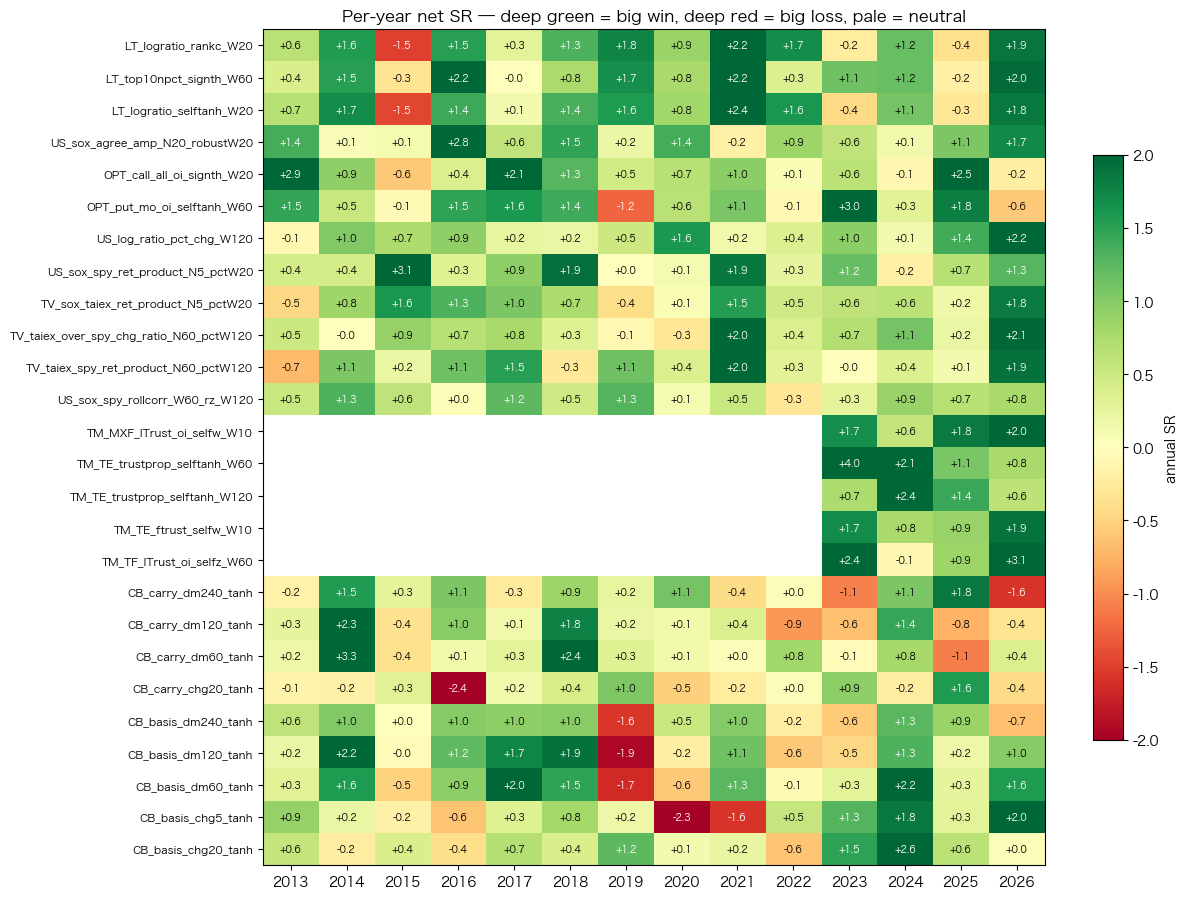

In [63]:
ret = ASSET["close"].pct_change()
cost_pct = 20.0/(ASSET["close"]*50.0) + 0.00002

def per_year_sr(sig, start=EVAL_START, end=EVAL_END):
    ex = sig.reindex(ASSET.index).shift(2)
    pnl = ((ex*ret) - ex.fillna(0).diff().abs()*cost_pct).loc[start:end].dropna()
    yr = pnl.groupby(pnl.index.year).apply(lambda x: (np.sqrt(252)*x.mean()/x.std()) if x.std() else np.nan)
    return yr

# All passers + all shorter-history candidates + all carry variants (for the 2026 discussion)
inspect_signals = list(p.index) + list(short_hist.index)
carry_variants = [k for k in SIGNED if k.startswith("CB_")]
inspect_signals += [k for k in carry_variants if k not in inspect_signals]

ys = pd.DataFrame({nm: per_year_sr(SIGNED[nm]) for nm in inspect_signals}).T
# Only show years >= 2013
ys = ys.loc[:, ys.columns >= 2013]

print(f"=== Annual net SR — {len(ys)} signals × {len(ys.columns)} years ===\n")

fig, ax = plt.subplots(figsize=(max(10, len(ys.columns)*0.9), max(6, len(ys)*0.35)))
im = ax.imshow(ys.values, cmap="RdYlGn", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(ys.columns))); ax.set_xticklabels(ys.columns, rotation=0)
ax.set_yticks(range(len(ys)));         ax.set_yticklabels(ys.index, fontsize=8)
for i in range(ys.shape[0]):
    for j in range(ys.shape[1]):
        v = ys.values[i, j]
        if np.isnan(v): continue
        ax.text(j, i, f"{v:+.1f}", ha="center", va="center",
                fontsize=7, color="white" if abs(v) > 1.2 else "black")
ax.set_title("Per-year net SR — deep green = big win, deep red = big loss, pale = neutral")
plt.colorbar(im, ax=ax, shrink=0.7, label="annual SR")
plt.tight_layout(); plt.show()


## 5. PnL correlation matrix on the passers

Only for the survivors — pairwise correlations of daily post-cost PnL. Low pairs = strong diversification benefit when combining.


corr matrix: (12, 12)   period 2013-01-02 → 2026-07-27


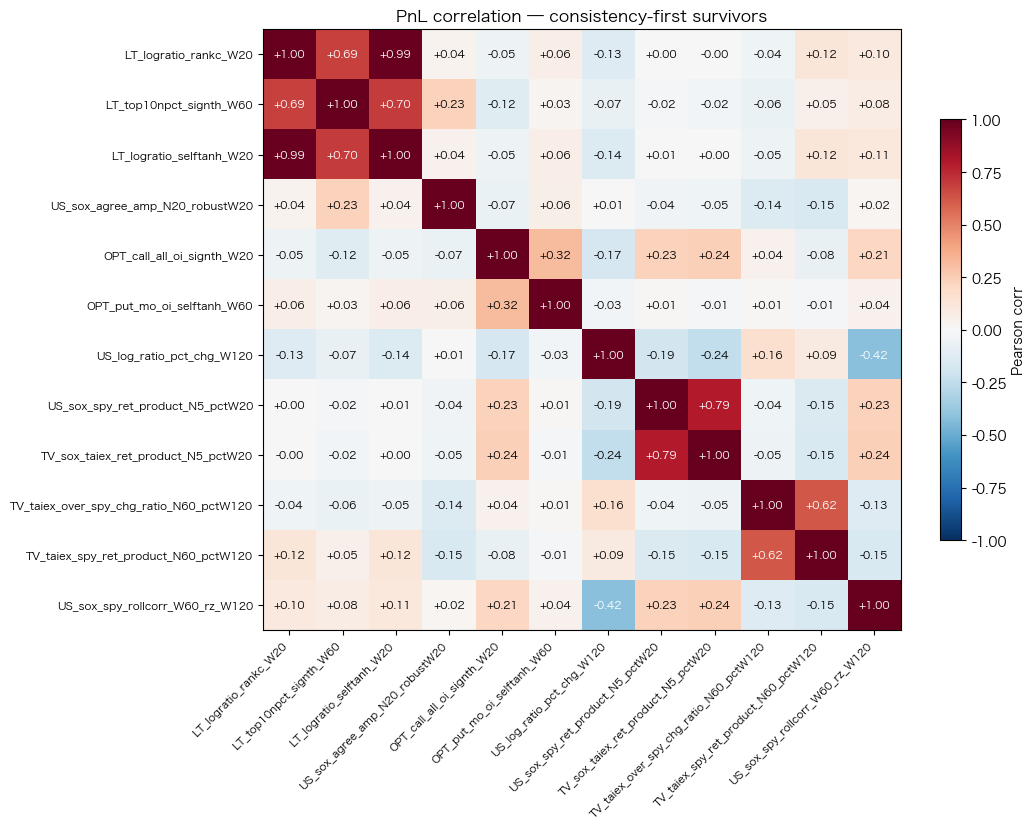


mean off-diag: +0.056   median: +0.003   max: +0.987   min: -0.417
|corr|<0.20: 52 / 66  diversifying


In [64]:
if len(p):
    pnl_panel = {}
    for nm in p.index:
        ex = SIGNED[nm].reindex(ASSET.index).shift(2)
        pnl_panel[nm] = ((ex*ret) - ex.fillna(0).diff().abs()*cost_pct).loc[EVAL_START:EVAL_END]
    pnl_df = pd.DataFrame(pnl_panel).dropna(how="all")
    corr = pnl_df.corr()
    print(f"corr matrix: {corr.shape}   period {pnl_df.index.min().date()} → {pnl_df.index.max().date()}")

    fig, ax = plt.subplots(figsize=(max(6, len(corr)*0.9), max(5, len(corr)*0.7)))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=8)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.values[i,j]:+.2f}", ha="center", va="center",
                    color="white" if abs(corr.values[i,j])>0.4 else "black", fontsize=8)
    ax.set_title("PnL correlation — consistency-first survivors")
    plt.colorbar(im, ax=ax, shrink=0.7, label="Pearson corr")
    plt.tight_layout(); plt.show()

    off = corr.values[np.triu_indices_from(corr.values, k=1)]
    print(f"\nmean off-diag: {off.mean():+.3f}   median: {np.median(off):+.3f}   "
          f"max: {off.max():+.3f}   min: {off.min():+.3f}")
    print(f"|corr|<0.20: {(np.abs(off)<0.20).sum()} / {len(off)}  diversifying")
else:
    print("no passers — nothing to correlate")


## 6. `SimulateAll` grid — cum PnL for each survivor


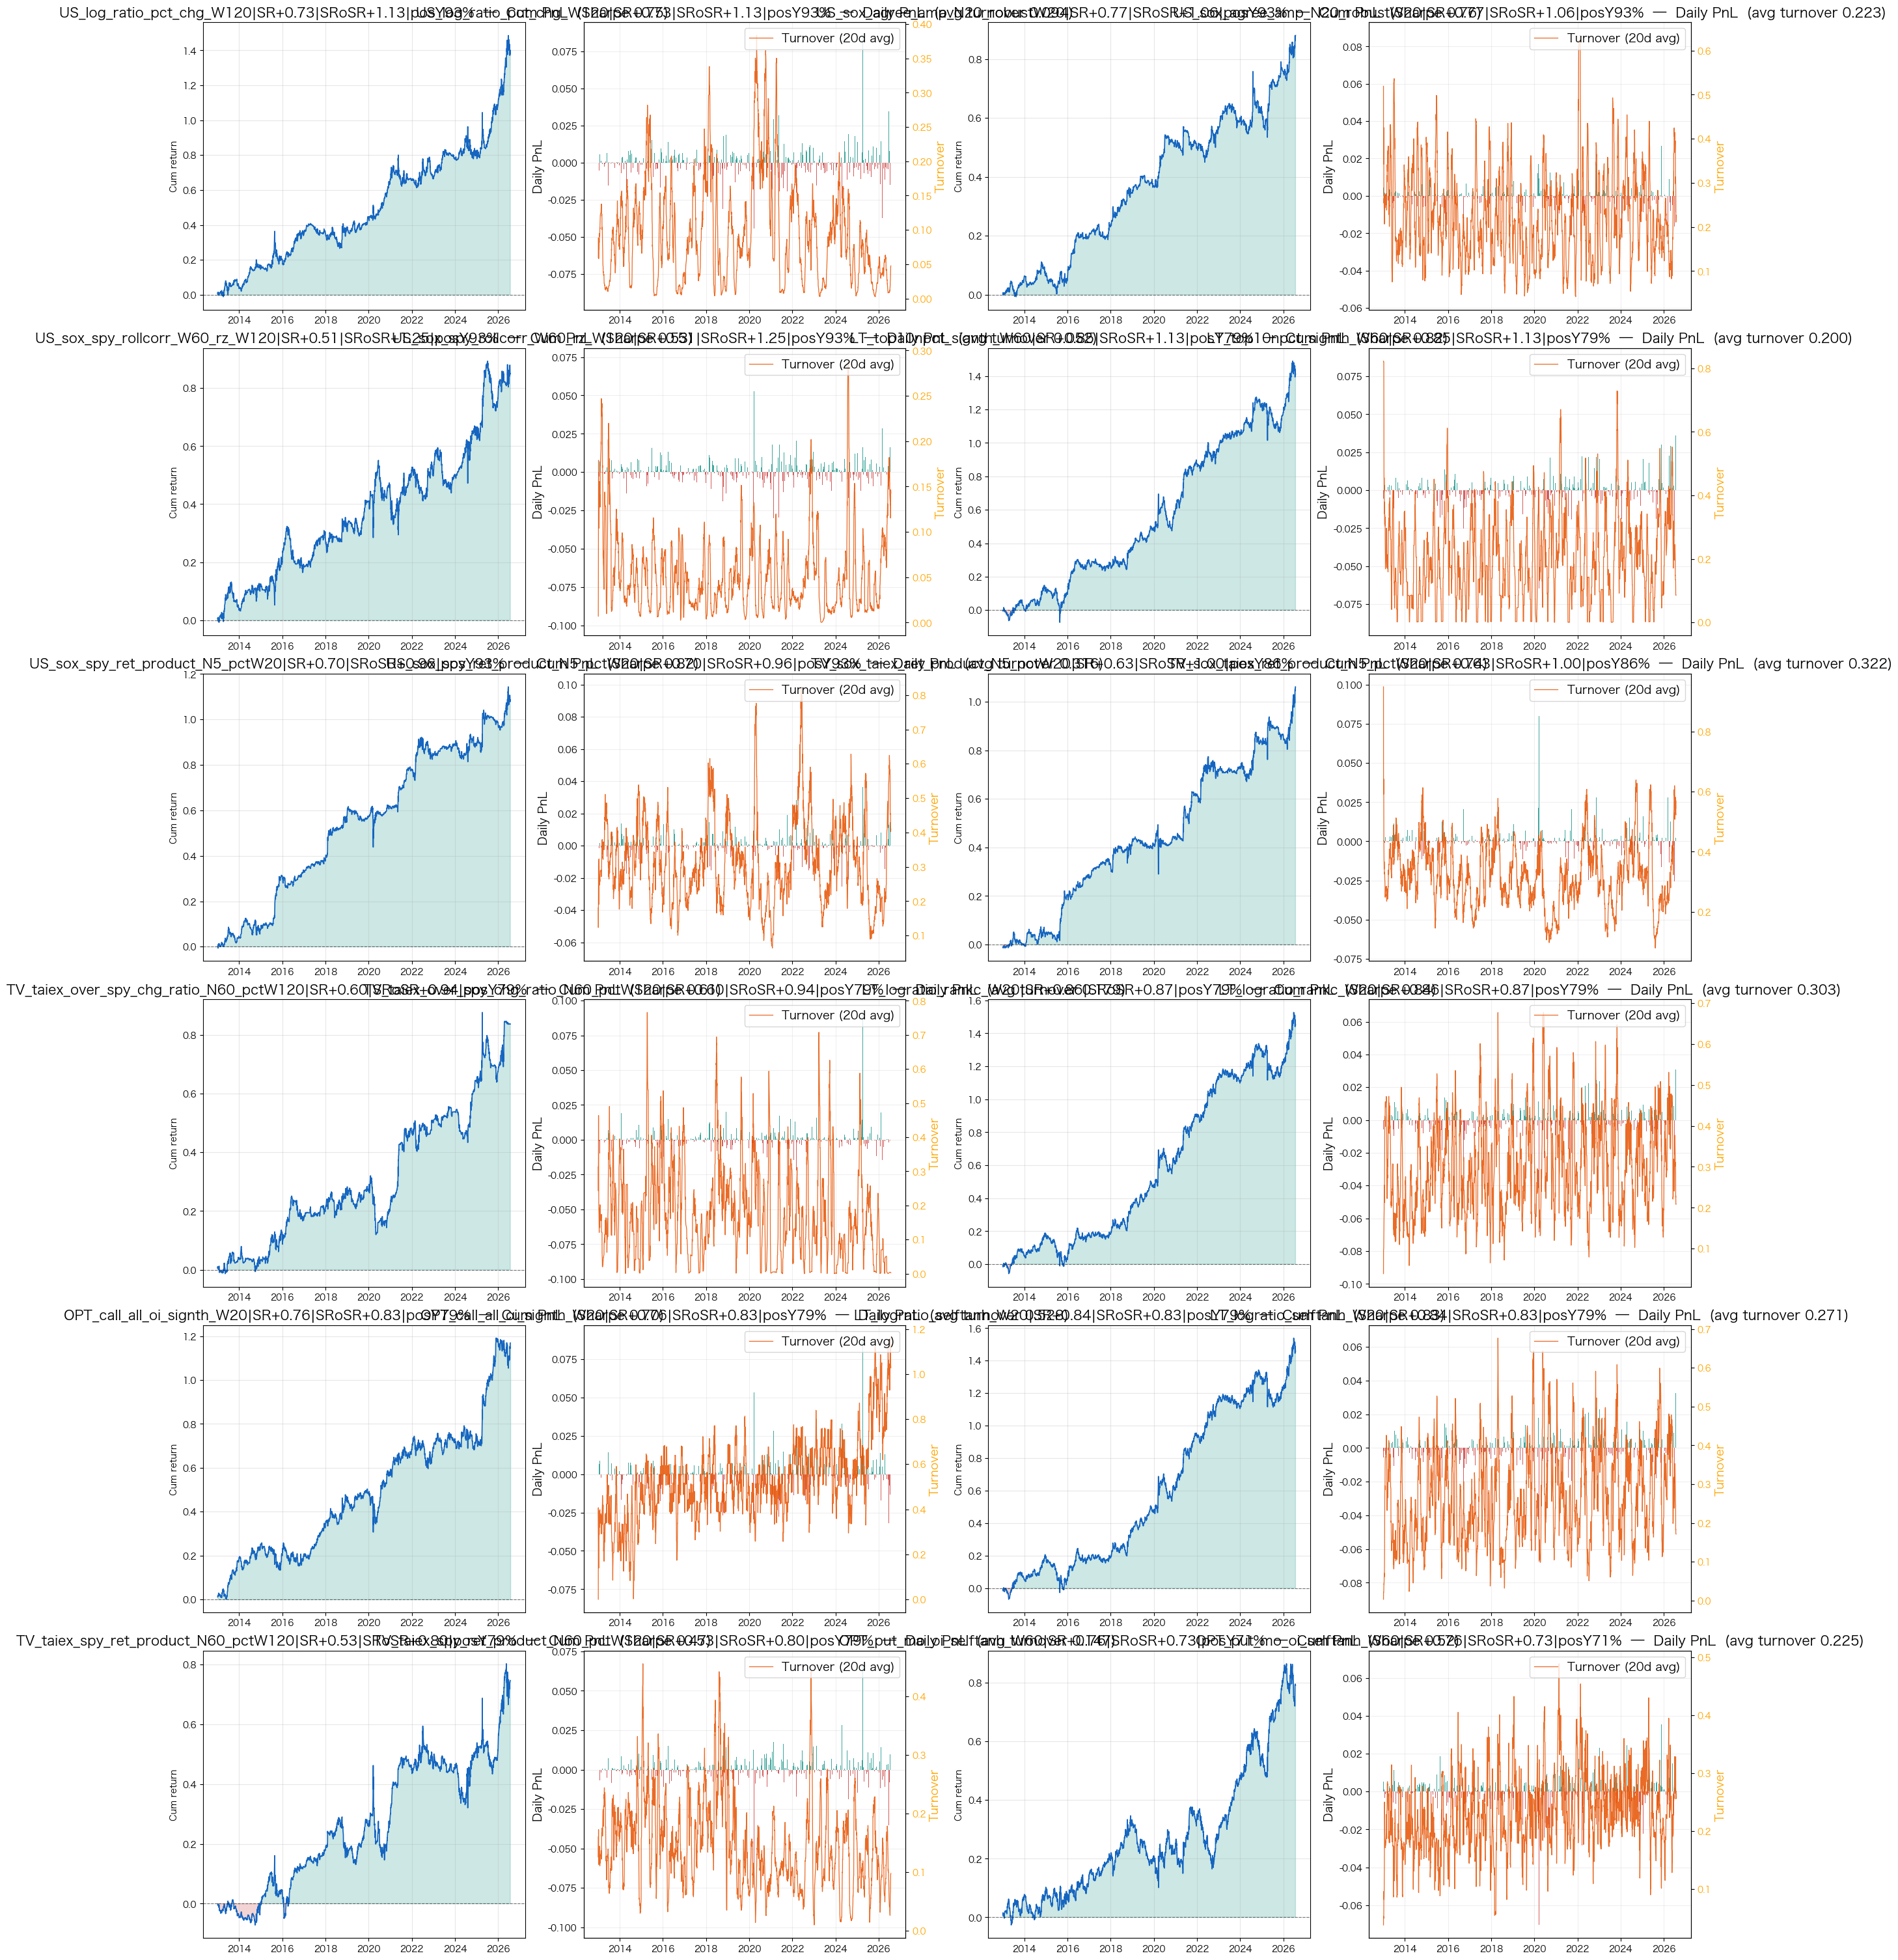

In [65]:
if len(p):
    ranked = p.sort_values("composite", ascending=False).index.tolist()
    sigs   = [SIGNED[k] for k in ranked]
    names  = [f"{k}|SR{r.loc[k,'SR_net']:+.2f}|SRoSR{r.loc[k,'SR_of_SR']:+.2f}|posY{r.loc[k,'pos_yr_pct']:.0f}%"
              for k in ranked]
    cta.SimulateAll(*sigs, names=names, asset="mtx", time_granularity="1d",
                    normalize=False, start_date=EVAL_START, end_date=EVAL_END)


## 7. `simulate_by_dollars` — realistic NTD $10M-account per-signal dashboards



  US_log_ratio_pct_chg_W120    SR +0.73  |  SR_of_SR +1.13  |  pos_yr 93%  |  worst_yr -0.09  |  max_dd 401d  |  α +11.7%/yr


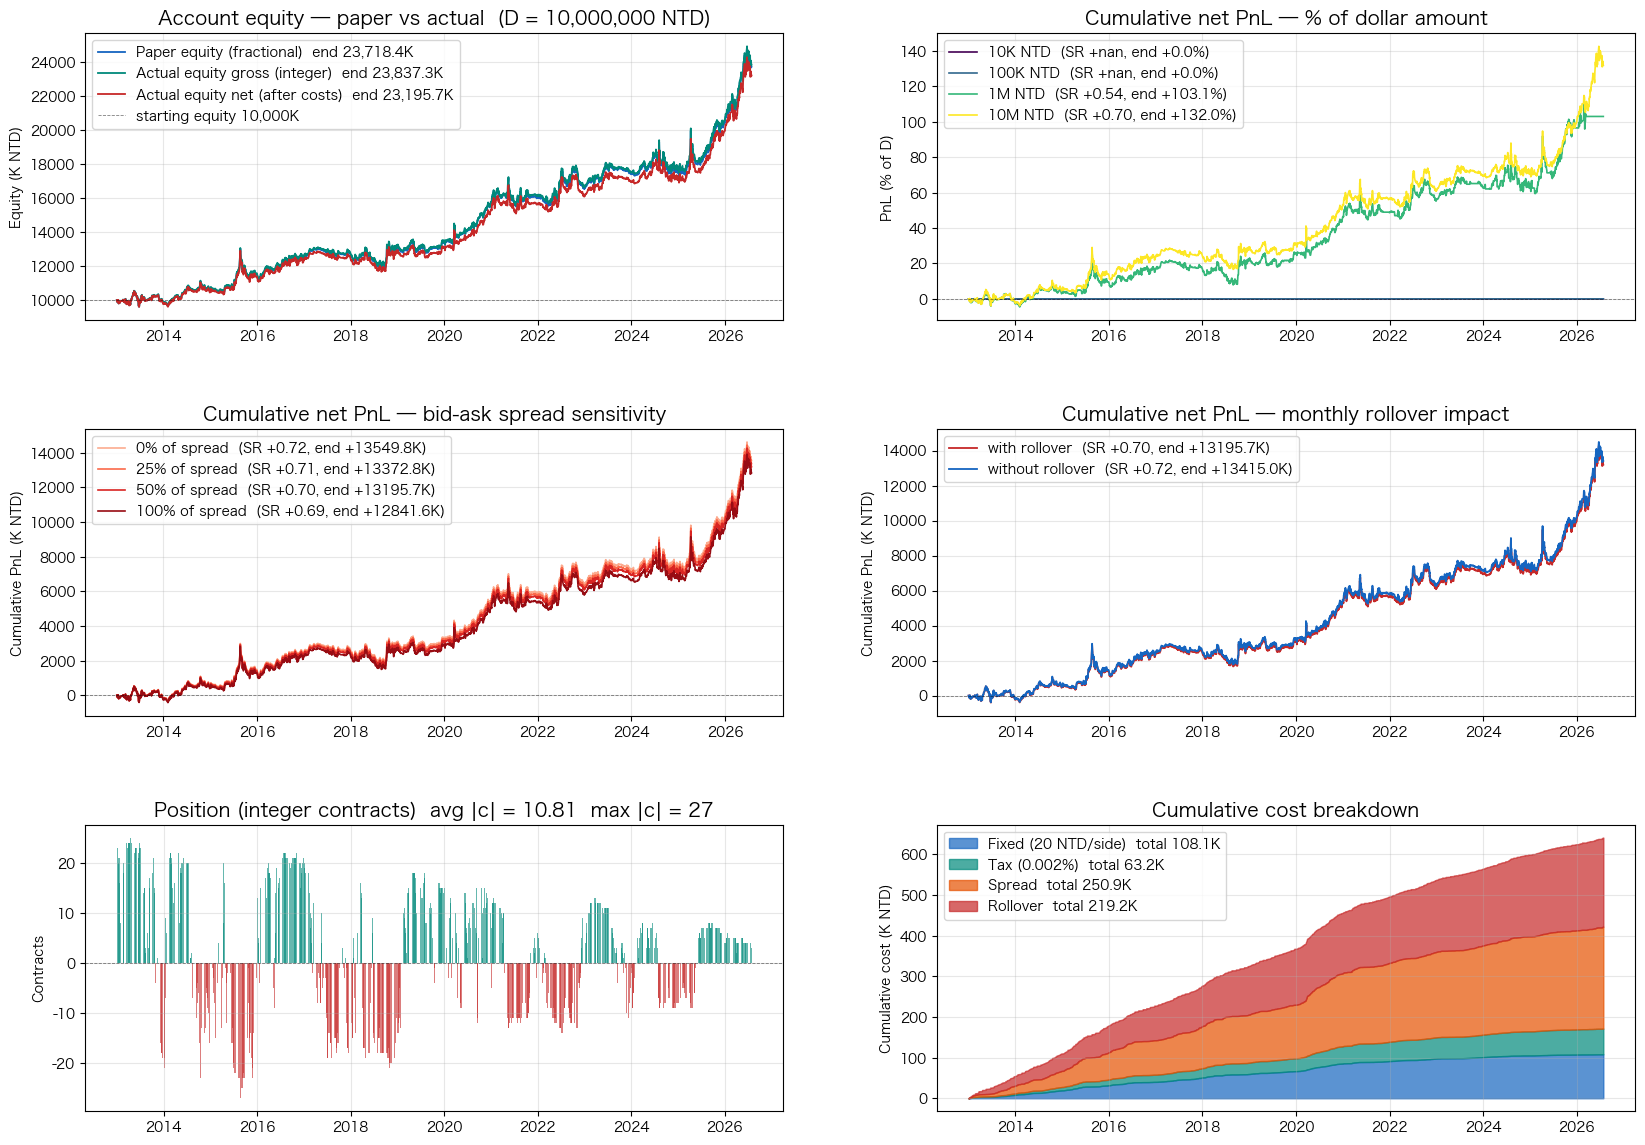


  US_sox_agree_amp_N20_robustW20    SR +0.77  |  SR_of_SR +1.06  |  pos_yr 93%  |  worst_yr -0.17  |  max_dd 318d  |  α +7.6%/yr


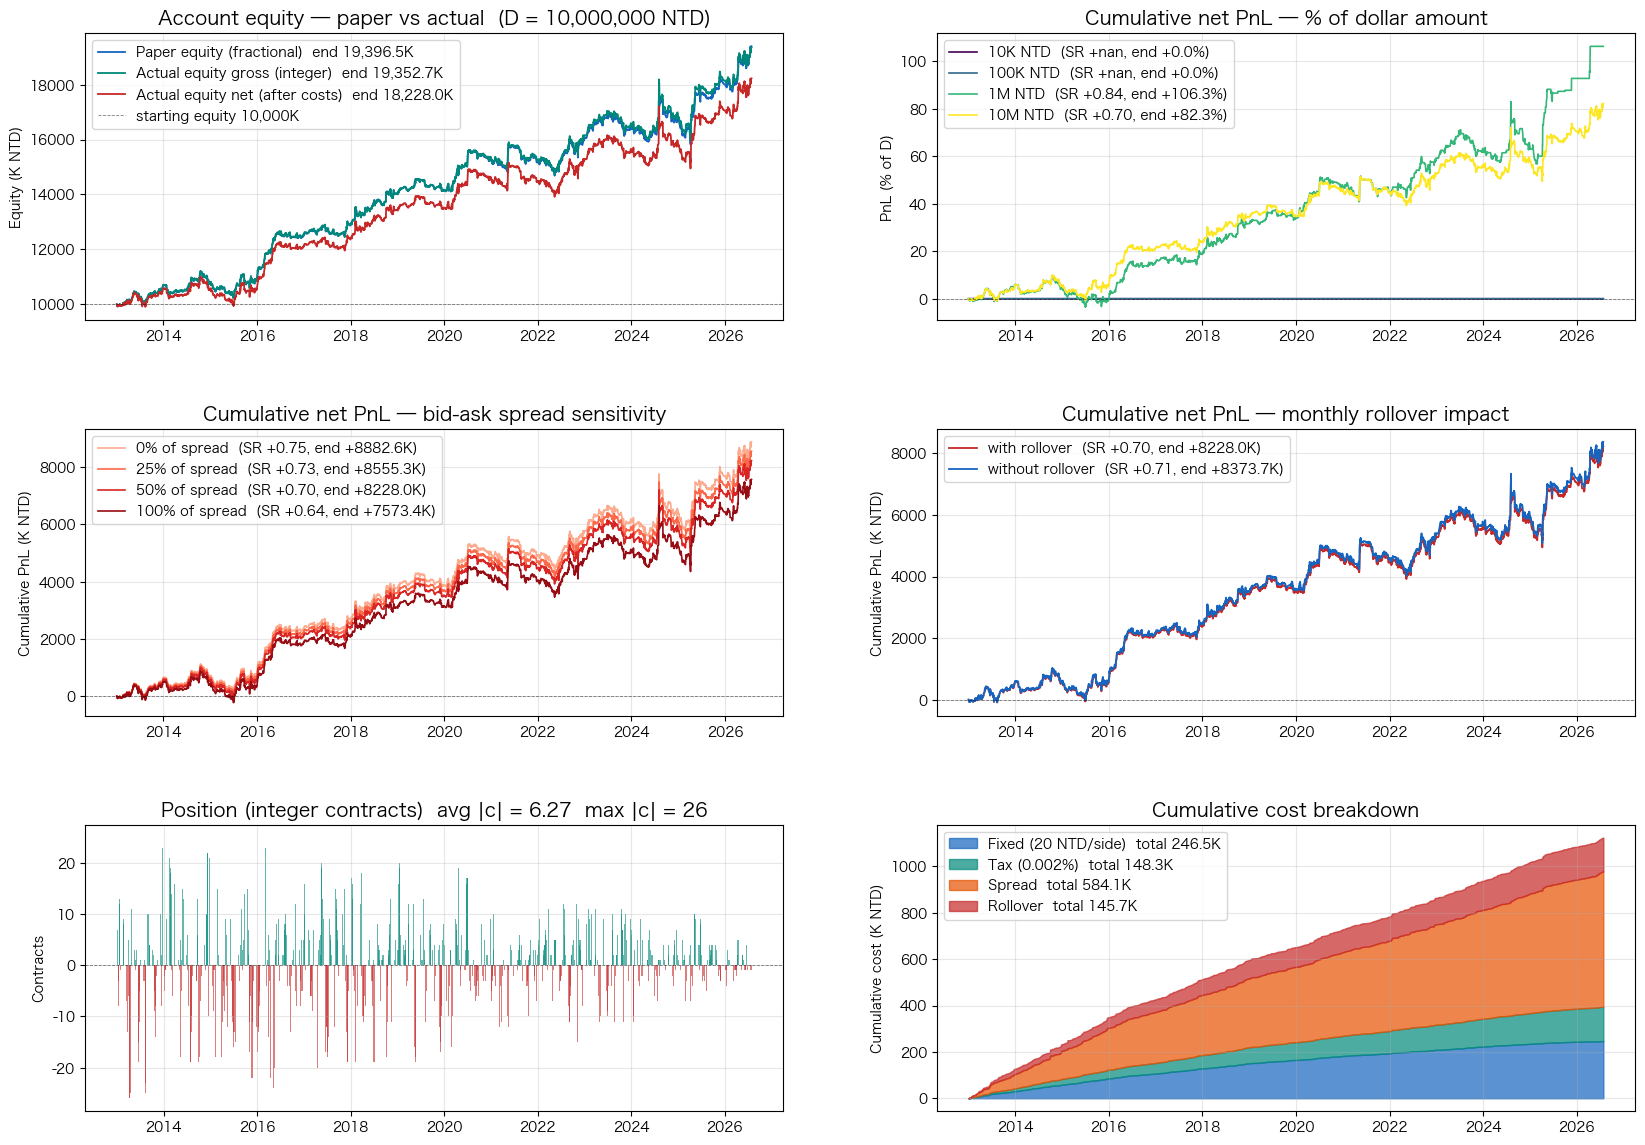


  US_sox_spy_rollcorr_W60_rz_W120    SR +0.51  |  SR_of_SR +1.25  |  pos_yr 93%  |  worst_yr -0.30  |  max_dd 631d  |  α +4.9%/yr


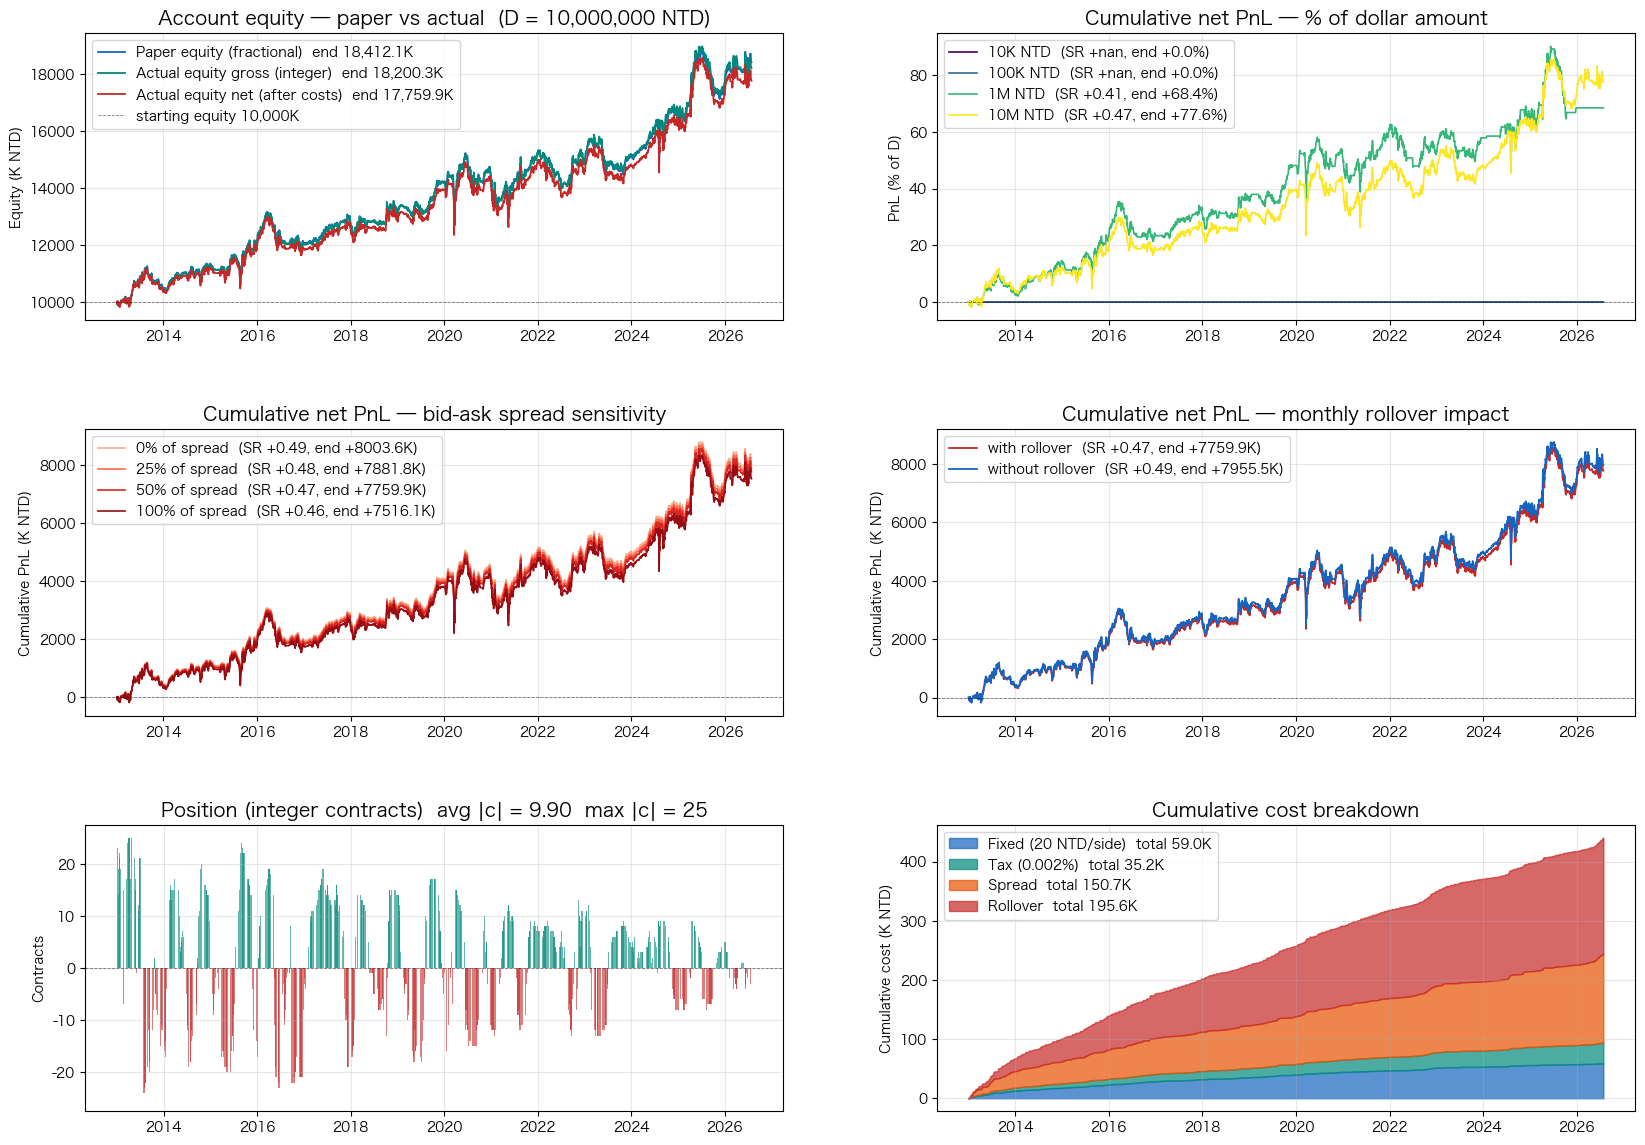


  LT_top10npct_signth_W60    SR +0.85  |  SR_of_SR +1.13  |  pos_yr 79%  |  worst_yr -0.33  |  max_dd 333d  |  α +12.6%/yr


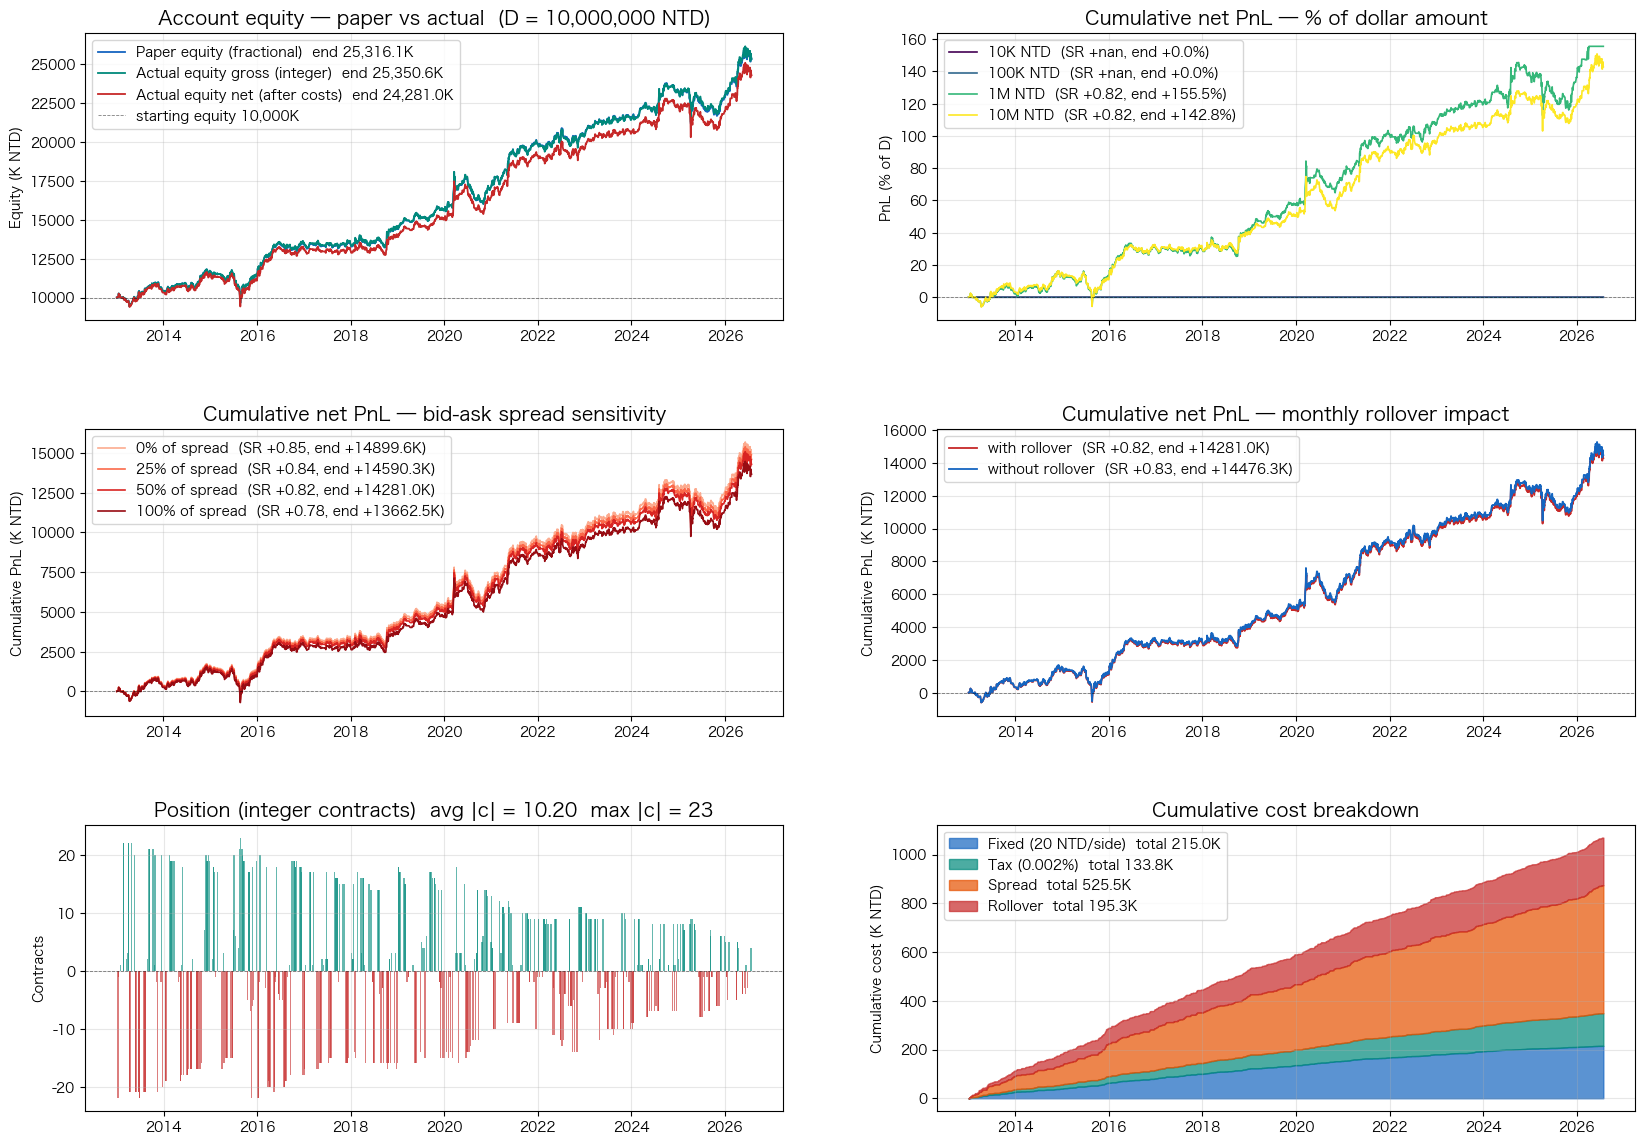


  US_sox_spy_ret_product_N5_pctW20    SR +0.70  |  SR_of_SR +0.96  |  pos_yr 93%  |  worst_yr -0.20  |  max_dd 683d  |  α +6.1%/yr


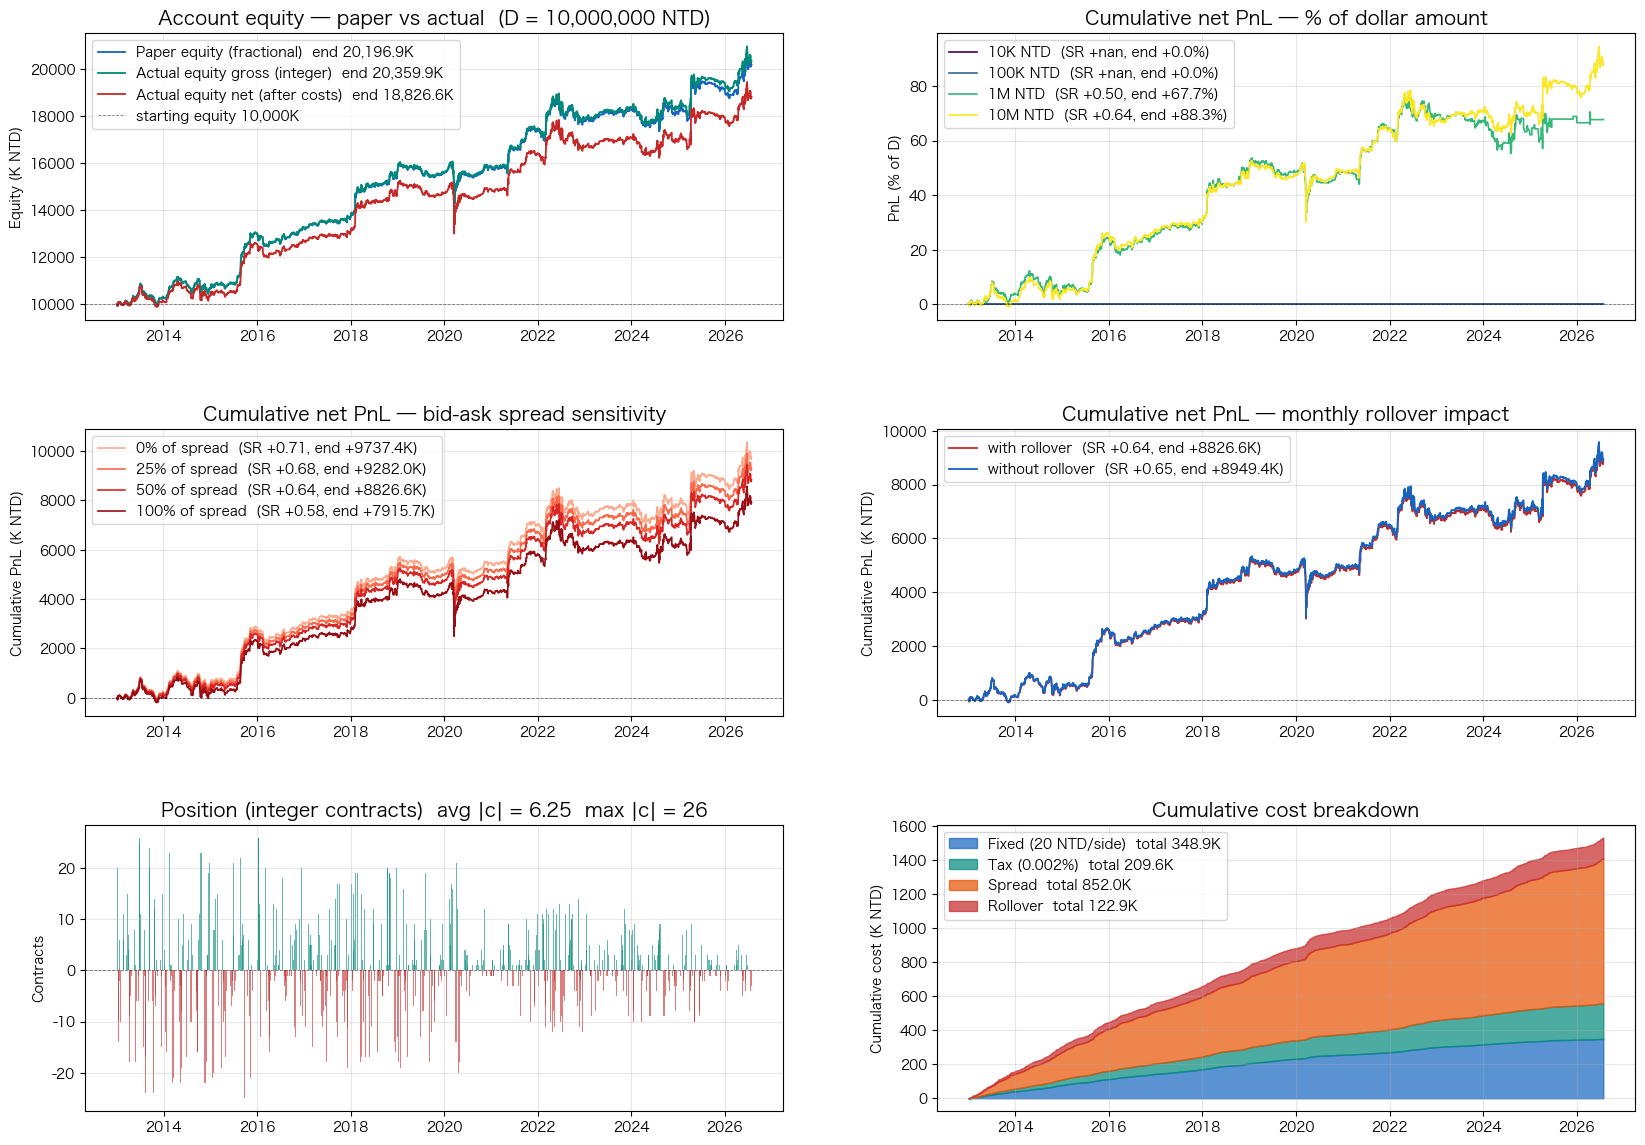


  TV_sox_taiex_ret_product_N5_pctW20    SR +0.63  |  SR_of_SR +1.00  |  pos_yr 86%  |  worst_yr -0.46  |  max_dd 509d  |  α +5.5%/yr


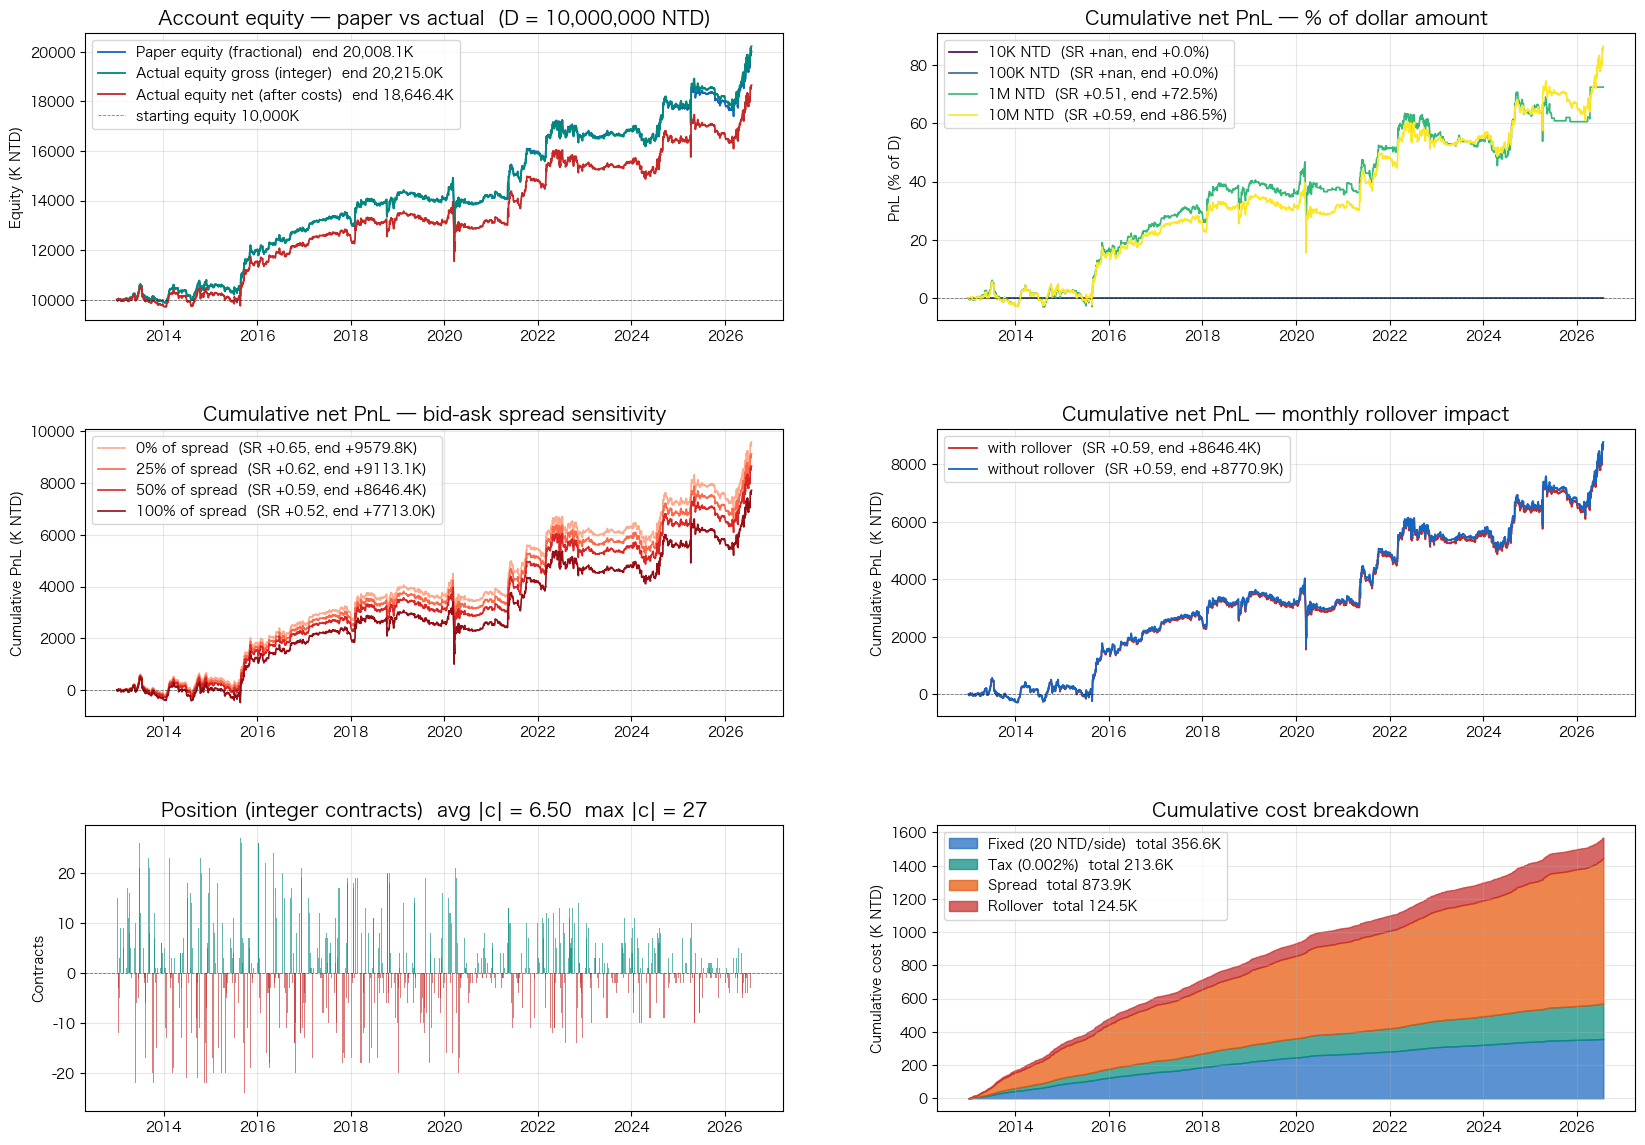


  TV_taiex_over_spy_chg_ratio_N60_pctW120    SR +0.60  |  SR_of_SR +0.94  |  pos_yr 79%  |  worst_yr -0.31  |  max_dd 400d  |  α +6.7%/yr


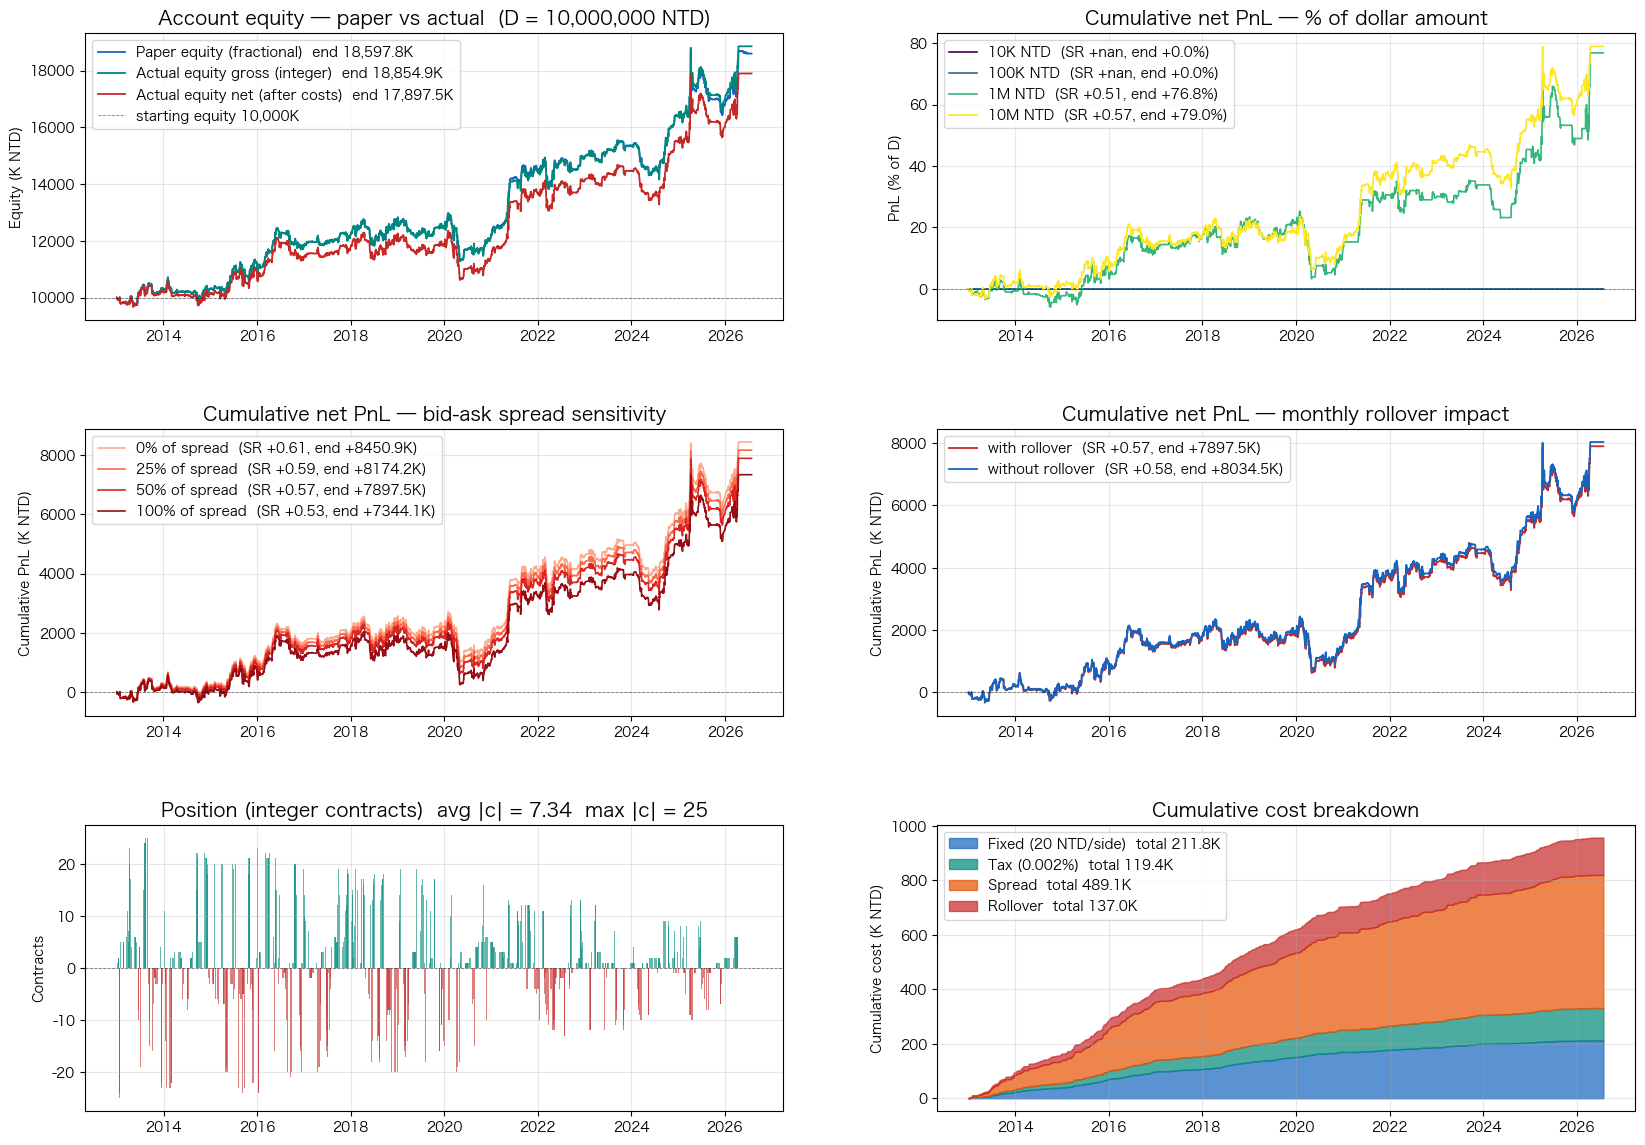


  LT_logratio_rankc_W20    SR +0.86  |  SR_of_SR +0.87  |  pos_yr 79%  |  worst_yr -1.50  |  max_dd 391d  |  α +12.2%/yr


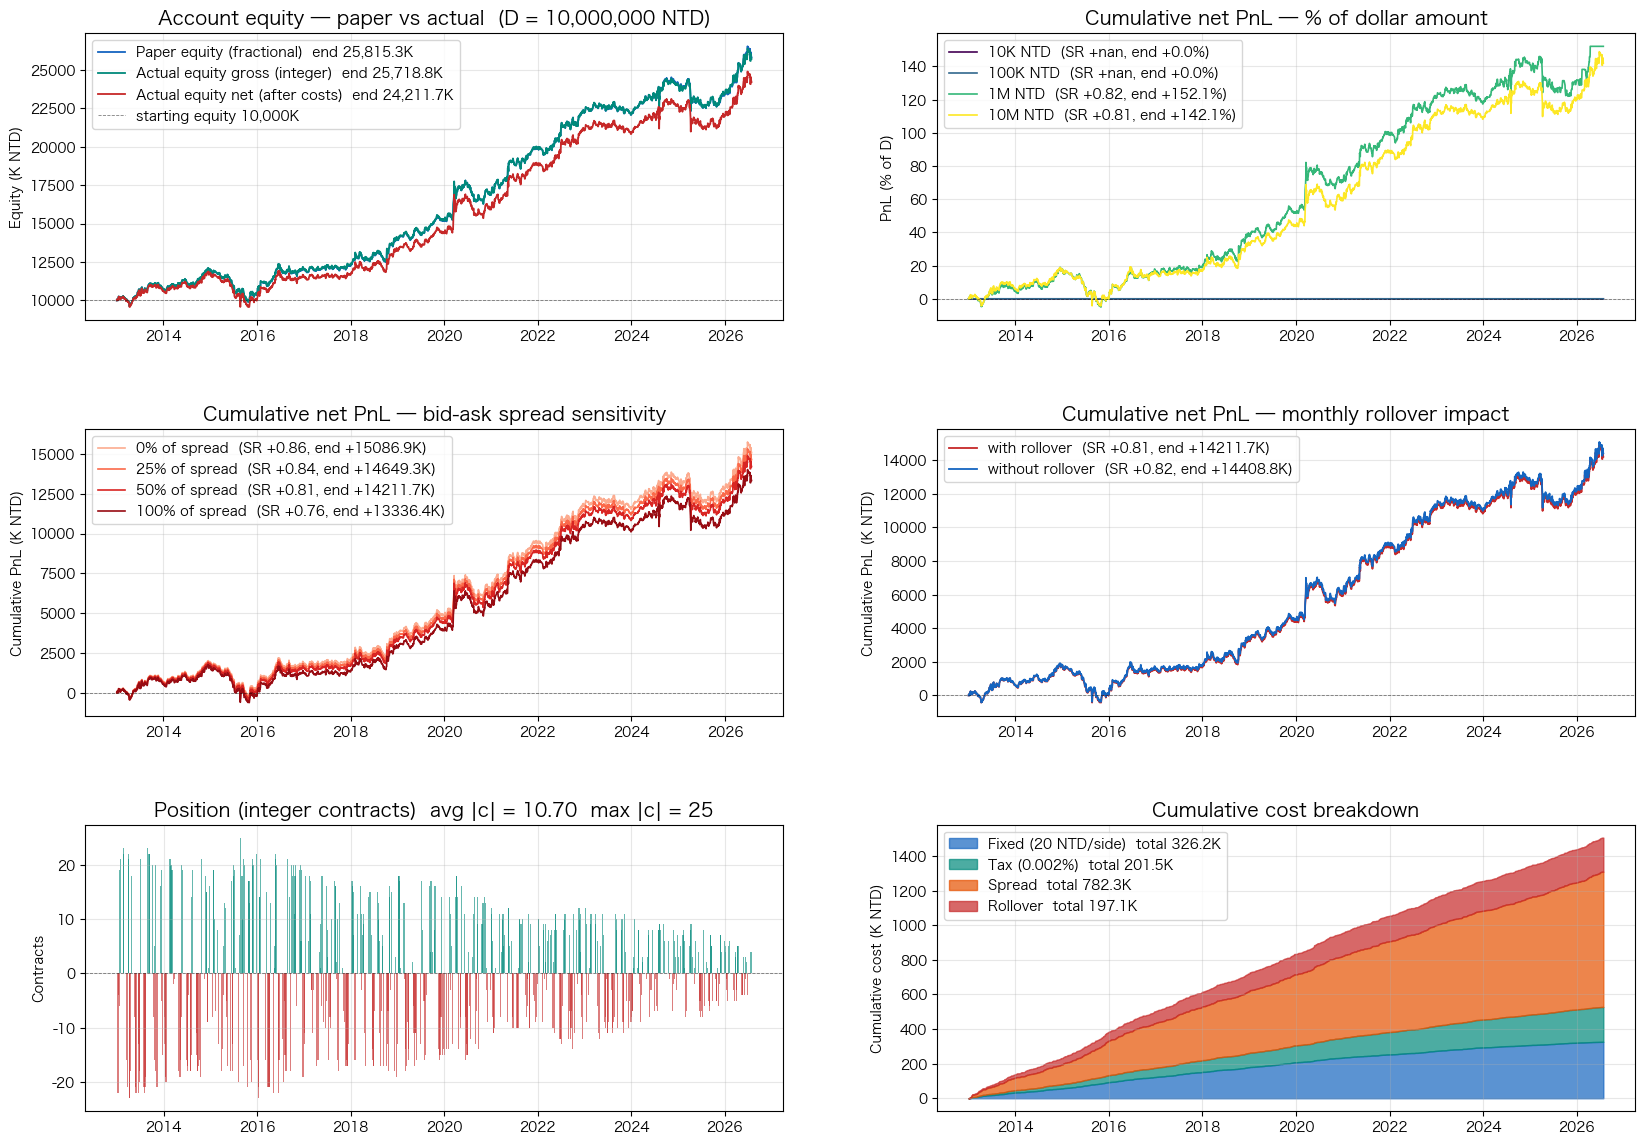


  OPT_call_all_oi_signth_W20    SR +0.76  |  SR_of_SR +0.83  |  pos_yr 79%  |  worst_yr -0.58  |  max_dd 313d  |  α +8.4%/yr


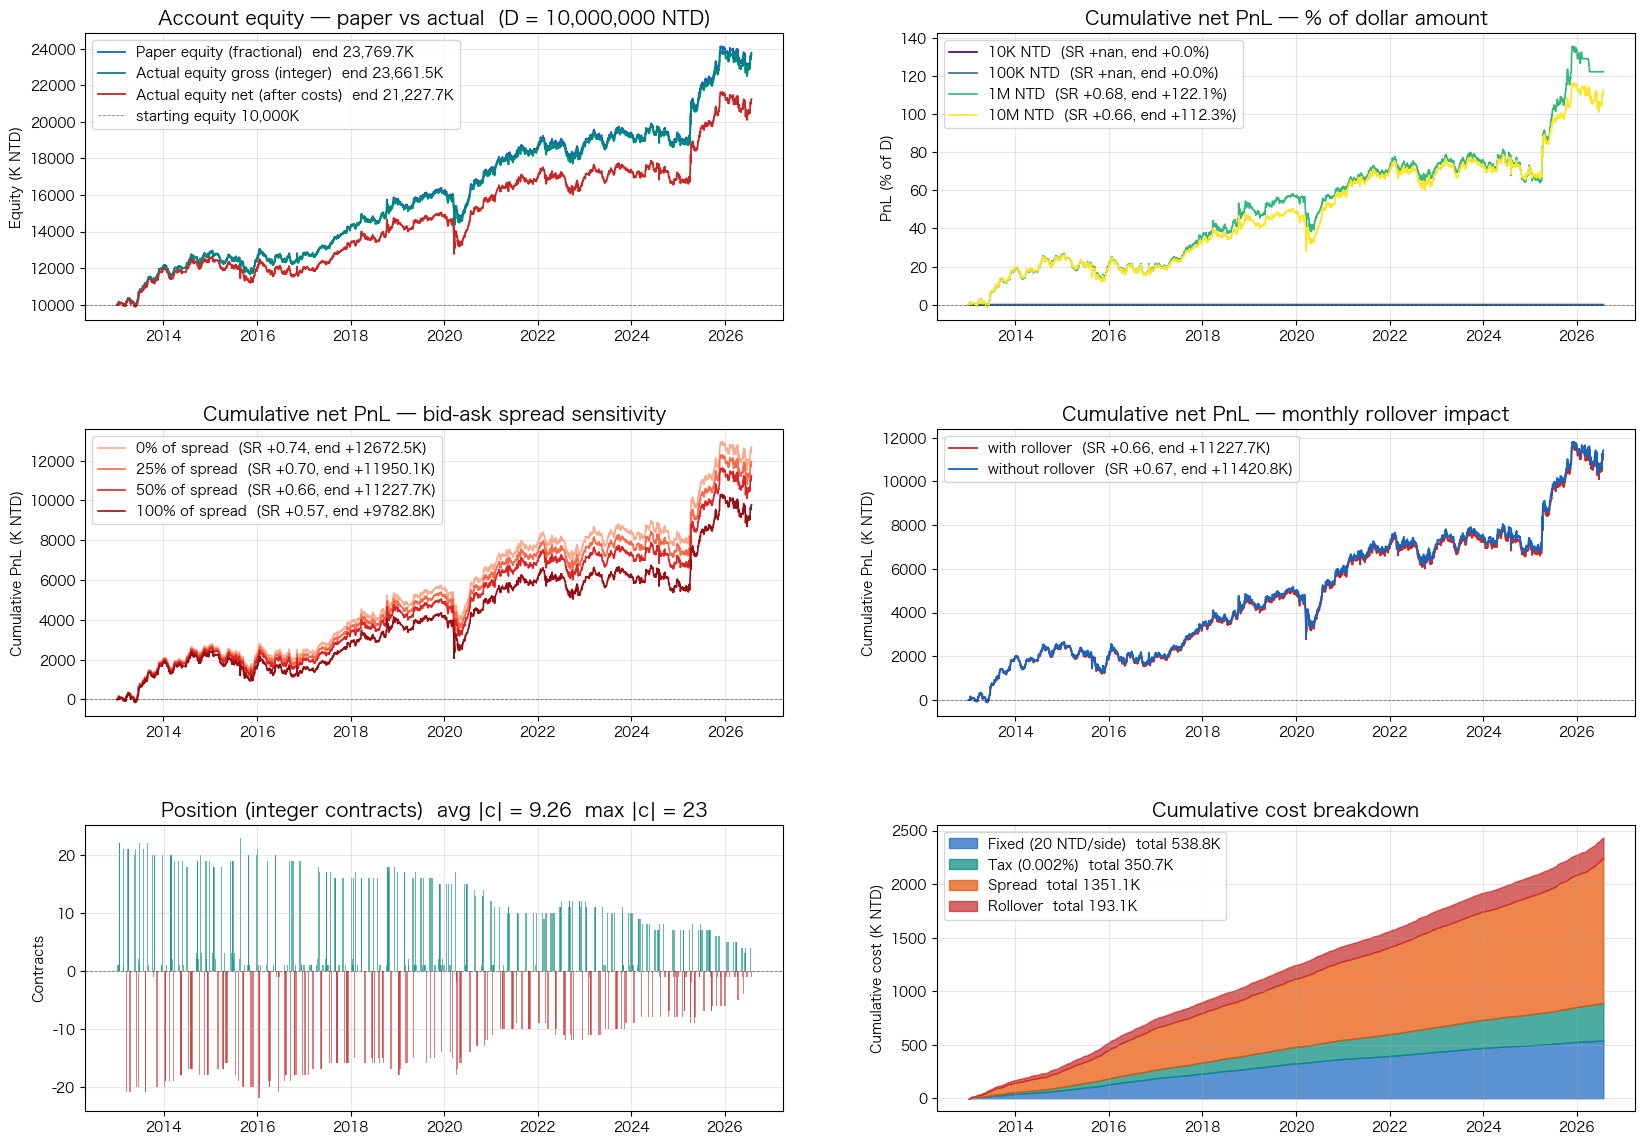


  LT_logratio_selftanh_W20    SR +0.84  |  SR_of_SR +0.83  |  pos_yr 79%  |  worst_yr -1.45  |  max_dd 390d  |  α +12.1%/yr


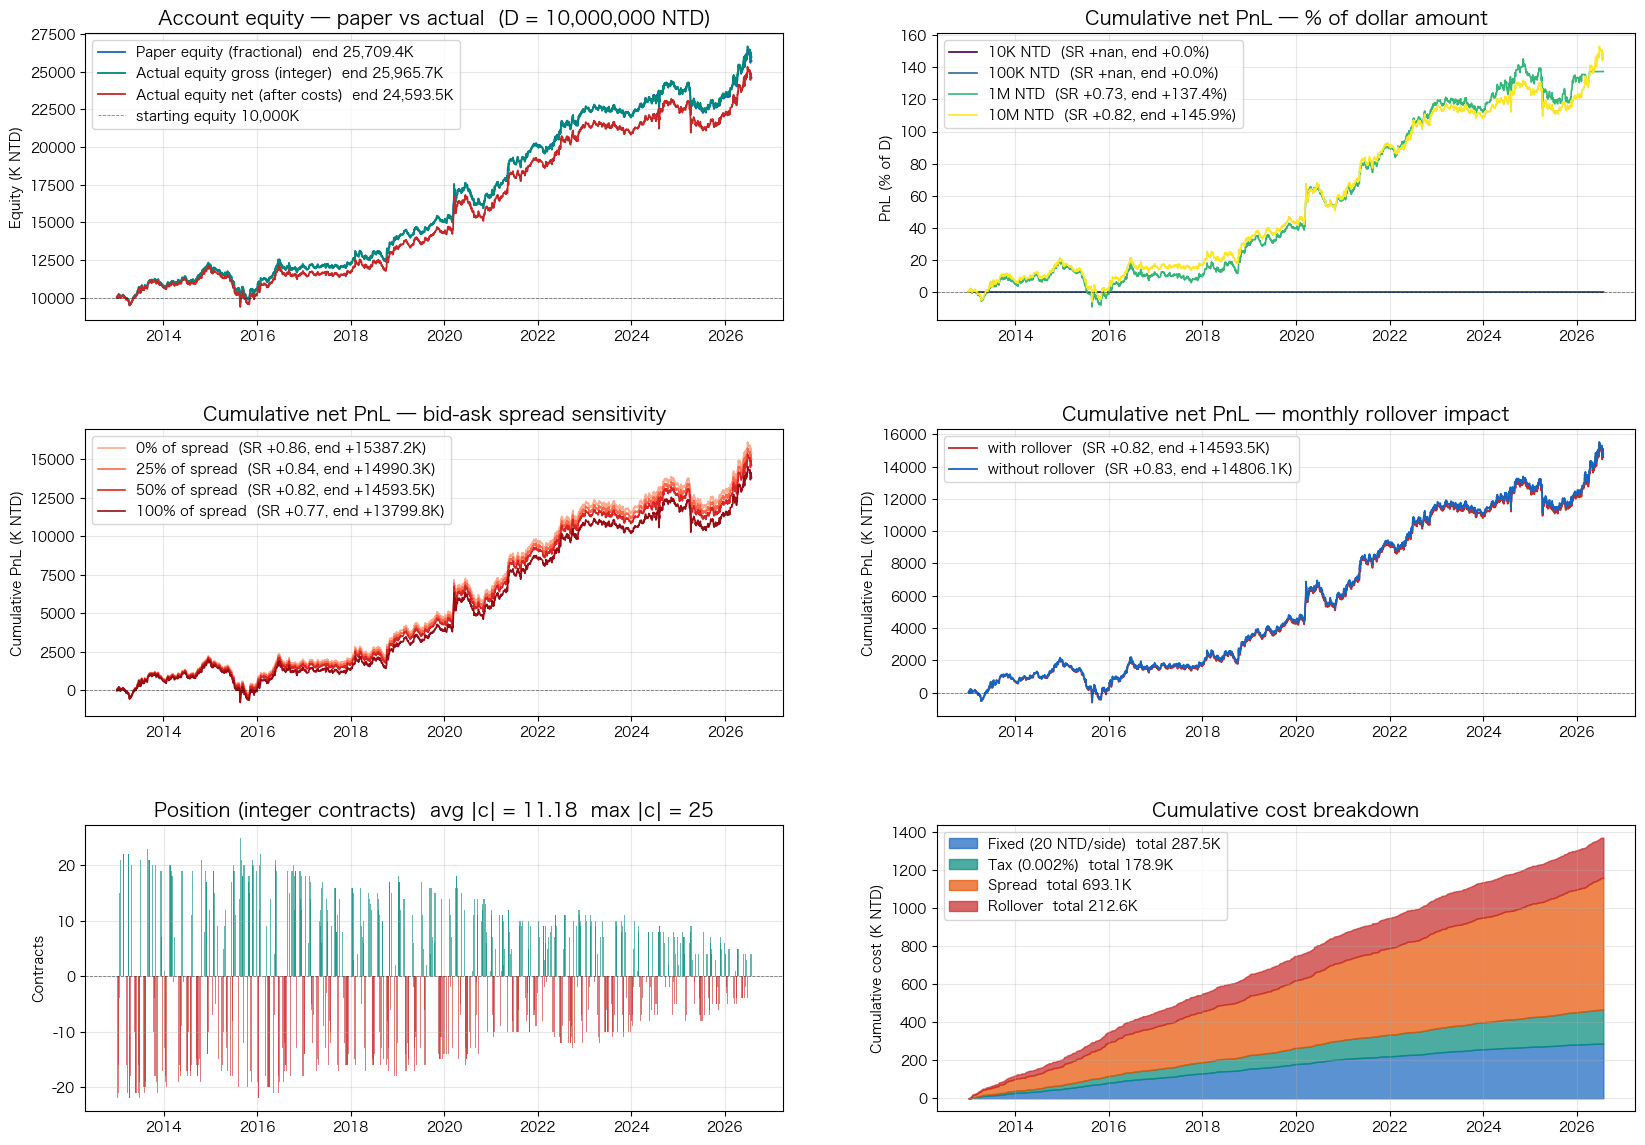


  TV_taiex_spy_ret_product_N60_pctW120    SR +0.53  |  SR_of_SR +0.80  |  pos_yr 79%  |  worst_yr -0.69  |  max_dd 663d  |  α +8.7%/yr


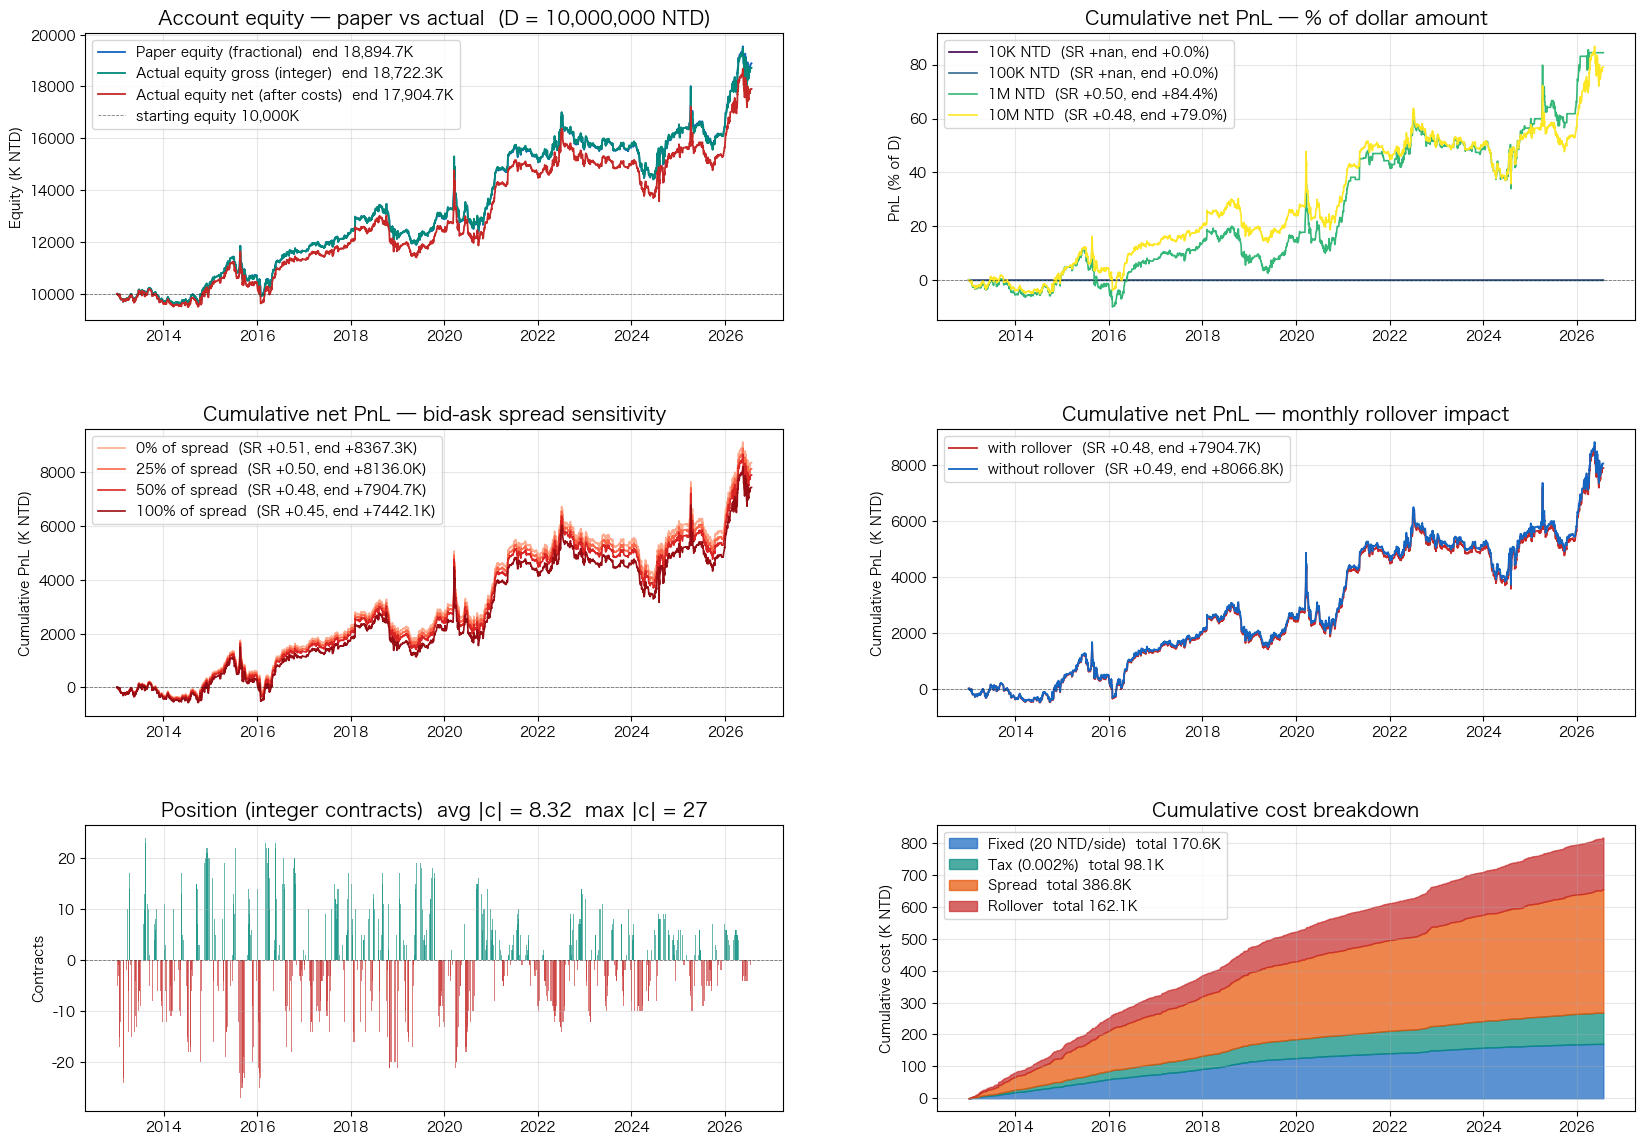


  OPT_put_mo_oi_selftanh_W60    SR +0.76  |  SR_of_SR +0.73  |  pos_yr 71%  |  worst_yr -1.24  |  max_dd 395d  |  α +8.9%/yr


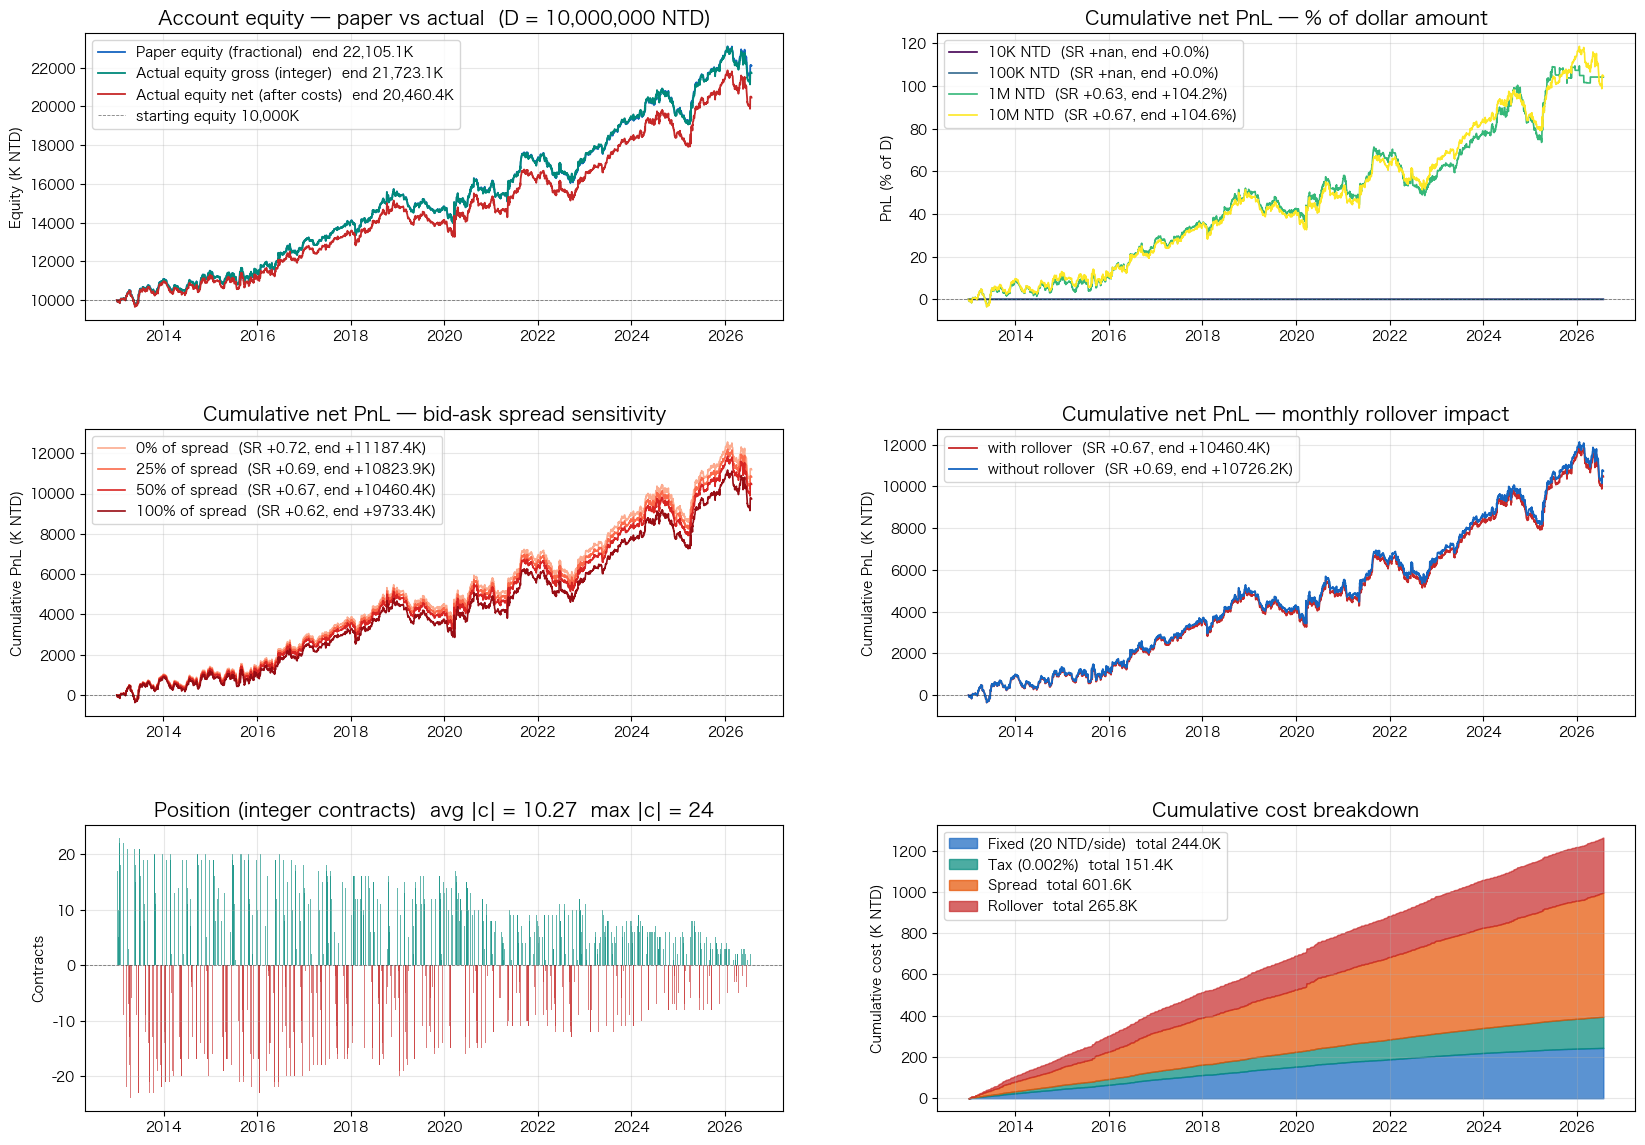

In [66]:
if len(p):
    DOLLAR = 10_000_000
    for k in p.sort_values("composite", ascending=False).index:
        row = r.loc[k]
        print("\n" + "="*100)
        print(f"  {k}    SR {row['SR_net']:+.2f}  |  SR_of_SR {row['SR_of_SR']:+.2f}  "
              f"|  pos_yr {row['pos_yr_pct']:.0f}%  |  worst_yr {row['yr_sr_min']:+.2f}  "
              f"|  max_dd {int(row['max_dd_days'])}d  |  α {row['alpha_ann_pct']:+.1f}%/yr")
        print("="*100)
        _ = cta.simulate_by_dollars(SIGNED[k], dollar_amount=DOLLAR, asset="mtx",
                                    time_granularity="1d", normalize=False,
                                    start_date=EVAL_START, end_date=EVAL_END)


## 8. Combining the survivors — which weighting scheme wins?

Six methods, all walk-forward-safe (rolling schemes use `shift(1)` to prevent look-ahead):

| method | formula | pros / cons |
|---|---|---|
| **equal_positions** | avg of the 5 signal columns, then trade | simplest; naturally smooths turnover cost |
| equal_pnl | sum of each signal's PnL / 5 | equivalent to holding 1 unit of each — slightly higher turnover cost than equal_positions |
| vol_parity_static | weight = 1/full-sample-vol per signal, normalized | uses future info — reference only, not a real strategy |
| **vol_parity_roll252** | weight = 1/trailing-252d-vol, applied next day | risk-parity, walk-forward-safe |
| recent_sr_roll252 | weight = max(trailing-252d SR, 0), normalized | rewards recent winners — risks overfitting to recent regime |
| recent_sr_roll504 | same, longer 504d lookback | less noisy but slower to adapt |
| softmax_sr_roll252 | softmax(trailing SR, temp=0.5) | never fully zeros a signal; middle ground |

Bottom line up front: **equal-weight and vol-parity beat everything** (SR ≈ 1.34). Recent-SR weighting UNDERPERFORMS because it whips into recent-winners right before those signals mean-revert.


In [67]:
# ── § 8.1  Build 7 combination methods over the 5 survivors ───────────────

if not len(p):
    print("No survivors — run § 3 first.")
else:
    SURVIVOR_NAMES = list(p.sort_values("composite", ascending=False).index)
    SIG = pd.DataFrame({n: SIGNED[n].reindex(ASSET.index) for n in SURVIVOR_NAMES}
                        ).loc[EVAL_START:EVAL_END]

    ret_srs   = ASSET["close"].pct_change()
    cost_pct2 = 20.0 / (ASSET["close"] * 50.0) + 0.00002

    def pnl_of(sig_col):
        ex = sig_col.shift(2)
        return (ex * ret_srs) - ex.fillna(0).diff().abs() * cost_pct2

    PNL = pd.DataFrame({n: pnl_of(SIG[n]) for n in SIG.columns}).loc[EVAL_START:EVAL_END]

    combos = {}
    # Solo (for reference)
    for n in SIG.columns: combos[f"solo:{n}"] = PNL[n]
    # Equal
    combos["equal_positions"] = pnl_of(SIG.mean(axis=1))
    combos["equal_pnl"]       = PNL.sum(axis=1) / len(SIG.columns)
    # Vol parity (static reference, look-ahead)
    _vols = PNL.std(); _w = (1/_vols) / (1/_vols).sum()
    combos["vol_parity_static"] = (PNL * _w).sum(axis=1)
    # Vol parity (rolling, walk-forward)
    roll_vol = PNL.rolling(252, min_periods=60).std().shift(1)
    w_roll = 1.0 / roll_vol.replace(0, np.nan)
    w_roll = w_roll.div(w_roll.sum(axis=1), axis=0)
    combos["vol_parity_roll252"] = (PNL * w_roll).sum(axis=1)
    # Recent-SR weighting
    roll_sr = (PNL.rolling(252, min_periods=60).mean() * np.sqrt(252)
               / PNL.rolling(252, min_periods=60).std()).shift(1)
    w_sr = roll_sr.clip(lower=0); _sum = w_sr.sum(axis=1).replace(0, np.nan)
    w_sr = w_sr.div(_sum, axis=0)
    combos["recent_sr_roll252"] = (PNL * w_sr).sum(axis=1)
    roll_sr2 = (PNL.rolling(504, min_periods=120).mean() * np.sqrt(252)
                / PNL.rolling(504, min_periods=120).std()).shift(1)
    w_sr2 = roll_sr2.clip(lower=0); _s2 = w_sr2.sum(axis=1).replace(0,np.nan)
    w_sr2 = w_sr2.div(_s2, axis=0)
    combos["recent_sr_roll504"] = (PNL * w_sr2).sum(axis=1)
    # Softmax (temperature 0.5)
    def _softmax(x, temp=1.0):
        x2 = x.sub(x.max(axis=1), axis=0)
        e = np.exp(x2/temp); return e.div(e.sum(axis=1), axis=0)
    w_sm = _softmax(roll_sr.fillna(0), temp=0.5)
    combos["softmax_sr_roll252"] = (PNL * w_sm).sum(axis=1)

    print(f"built {len(combos) - len(SIG.columns)} combination methods over {len(SIG.columns)} survivors")


built 7 combination methods over 12 survivors


In [68]:
# ── § 8.2  Compare all methods — full-history stats + 2026 YTD ────────────

def _sr(x):
    x = x.dropna(); return float(np.sqrt(252) * x.mean() / x.std()) if x.std() > 0 else np.nan
def _max_dd_days(x):
    cum = x.cumsum(); dd = (cum - cum.cummax()) < 0
    if not dd.any(): return 0
    runs = dd.astype(int).groupby((dd != dd.shift()).cumsum()).sum()
    return int(runs.max())
def _stats(pnl, label):
    a = pnl.dropna()
    if len(a) == 0: return {"label": label, "SR": np.nan}
    ann_ret = a.mean() * 252; ann_vol = a.std() * np.sqrt(252)
    dd = a.cumsum() - a.cumsum().cummax()
    calmar = ann_ret / abs(dd.min()) if dd.min() < 0 else np.nan
    yr = a.groupby(a.index.year).apply(lambda x: _sr(x)).dropna()
    return {"label": label, "SR": round(_sr(a), 3),
            "ann_ret_%": round(ann_ret*100, 2), "ann_vol_%": round(ann_vol*100, 2),
            "calmar": round(calmar, 3) if not np.isnan(calmar) else np.nan,
            "max_dd_d": _max_dd_days(a),
            "pos_yr_%": round((yr > 0).mean()*100, 1),
            "worst_yr_SR": round(yr.min(), 2) if len(yr) else np.nan,
            "SR_of_SR": round(_sr(yr), 3) if yr.std() else np.nan}

comb_stats = pd.DataFrame([_stats(v, k) for k, v in combos.items()]).set_index("label")
solo_mask  = comb_stats.index.str.startswith("solo:")

print("=== SOLO signals (baseline) ===")
display(comb_stats[solo_mask].round(3))

print("\n=== COMBINATION methods, ranked by full-history SR ===")
display(comb_stats[~solo_mask].sort_values("SR", ascending=False).round(3))

# 2026 YTD
print("\n=== 2026 YTD SR by method ===")
rows_2026 = []
for k, v in combos.items():
    if k.startswith("solo:"): continue
    ytd = v.loc["2026-01-01":]
    rows_2026.append({"method": k, "2026_SR": round(_sr(ytd), 3),
                       "2026_ann_ret_%": round(ytd.mean()*252*100, 2)})
display(pd.DataFrame(rows_2026).sort_values("2026_SR", ascending=False))


=== SOLO signals (baseline) ===


,SR,ann_ret_%,ann_vol_%,calmar,max_dd_d,pos_yr_%,worst_yr_SR,SR_of_SR
label,,,,,,,,
solo:US_log_ratio_pct_chg_W120,0.723,10.32,14.28,0.512,401,92.9,-0.23,17.307
solo:US_sox_agree_amp_N20_robustW20,0.763,6.86,8.99,0.306,318,92.9,-0.17,16.792
solo:US_sox_spy_rollcorr_W60_rz_W120,0.509,6.34,12.46,0.279,631,92.9,-0.30,19.677
solo:LT_top10npct_signth_W60,0.857,11.41,13.31,0.437,333,78.6,-0.33,18.026
solo:US_sox_spy_ret_product_N5_pctW20,0.704,7.34,10.43,0.338,683,92.9,-0.20,15.183
solo:TV_sox_taiex_ret_product_N5_pctW20,0.640,7.19,11.23,0.301,509,85.7,-0.41,16.597
solo:TV_taiex_over_spy_chg_ratio_N60_pctW120,0.597,6.30,10.55,0.277,400,78.6,-0.31,14.552
solo:LT_logratio_rankc_W20,0.871,11.65,13.37,0.521,391,78.6,-1.49,14.093
solo:OPT_call_all_oi_signth_W20,0.754,9.85,13.07,0.432,313,78.6,-0.58,13.287



=== COMBINATION methods, ranked by full-history SR ===


,SR,ann_ret_%,ann_vol_%,calmar,max_dd_d,pos_yr_%,worst_yr_SR,SR_of_SR
label,,,,,,,,
equal_positions,1.957,8.84,4.52,2.369,208,100.0,0.46,38.638
vol_parity_static,1.940,8.50,4.38,2.482,160,100.0,0.60,39.127
vol_parity_roll252,1.935,8.59,4.44,2.600,160,100.0,0.61,40.944
equal_pnl,1.923,8.69,4.52,2.312,208,100.0,0.41,37.666
recent_sr_roll504,1.011,5.87,5.81,0.633,308,92.9,-0.30,21.138
recent_sr_roll252,0.803,5.49,6.84,0.437,329,92.9,-0.11,25.200
softmax_sr_roll252,0.552,4.75,8.62,0.370,559,92.9,-0.35,20.002



=== 2026 YTD SR by method ===


,method,2026_SR,2026_ann_ret_%
0,equal_positions,3.881,29.80
2,vol_parity_static,3.876,28.97
1,equal_pnl,3.867,29.69
3,vol_parity_roll252,3.814,28.57
5,recent_sr_roll504,2.812,20.08
4,recent_sr_roll252,1.244,11.01
6,softmax_sr_roll252,-0.347,-5.53


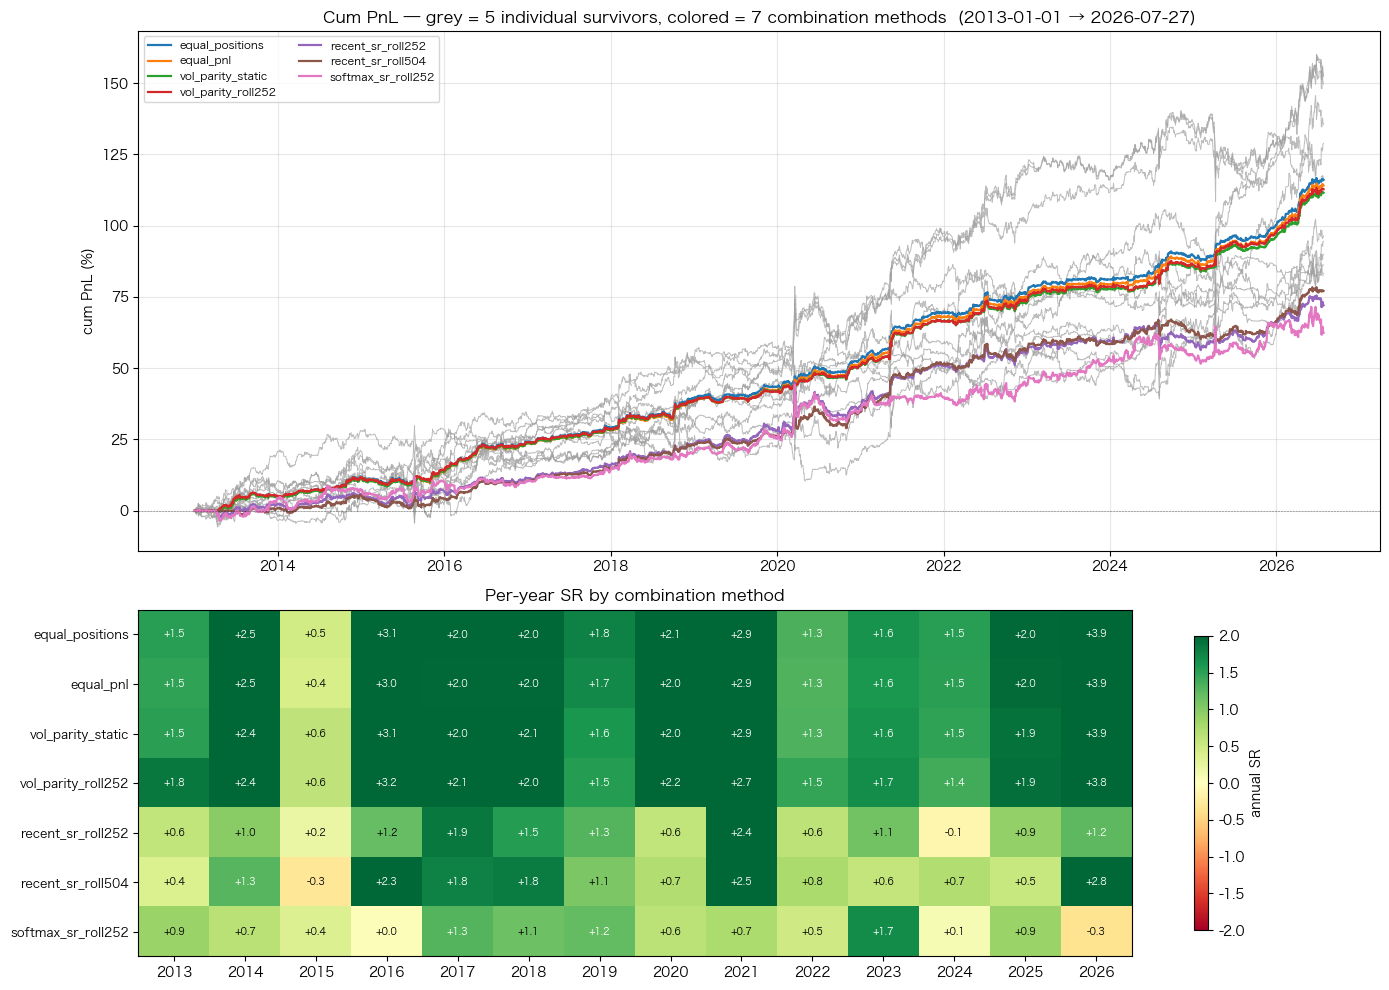

In [69]:
# ── § 8.3  Cum PnL comparison + per-year SR heatmap ───────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios":[3,2]})

# Panel 1 — cum PnL: solos in grey, combos in bold colors
ax = axes[0]
for n in SIG.columns:
    ax.plot(PNL[n].cumsum() * 100, lw=0.7, color="#a0a0a0", alpha=0.7)
palette = plt.cm.tab10.colors
i = 0
for k, v in combos.items():
    if k.startswith("solo:"): continue
    ax.plot(v.cumsum() * 100, lw=1.6, color=palette[i % 10], label=k)
    i += 1
ax.set_ylabel("cum PnL (%)")
ax.set_title(f"Cum PnL — grey = 5 individual survivors, colored = 7 combination methods  "
             f"({EVAL_START} → {EVAL_END})")
ax.axhline(0, color="black", lw=0.4, ls="--", alpha=0.5)
ax.legend(fontsize=8, loc="upper left", ncol=2)
ax.grid(alpha=0.3)

# Panel 2 — per-year SR heatmap for COMBINATION methods
combo_yr = {}
for k, v in combos.items():
    if k.startswith("solo:"): continue
    a = v.dropna()
    yr = a.groupby(a.index.year).apply(lambda x: _sr(x))
    combo_yr[k] = yr
ydf = pd.DataFrame(combo_yr).T
ydf = ydf.loc[:, ydf.columns >= 2013]

ax = axes[1]
im = ax.imshow(ydf.values, cmap="RdYlGn", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(ydf.columns))); ax.set_xticklabels(ydf.columns)
ax.set_yticks(range(len(ydf))); ax.set_yticklabels(ydf.index, fontsize=9)
for i in range(ydf.shape[0]):
    for j in range(ydf.shape[1]):
        v = ydf.values[i, j]
        if np.isnan(v): continue
        ax.text(j, i, f"{v:+.1f}", ha="center", va="center",
                fontsize=7, color="white" if abs(v) > 1.2 else "black")
ax.set_title("Per-year SR by combination method")
plt.colorbar(im, ax=ax, shrink=0.85, label="annual SR")
plt.tight_layout(); plt.show()


best combo by full-history SR: equal_positions


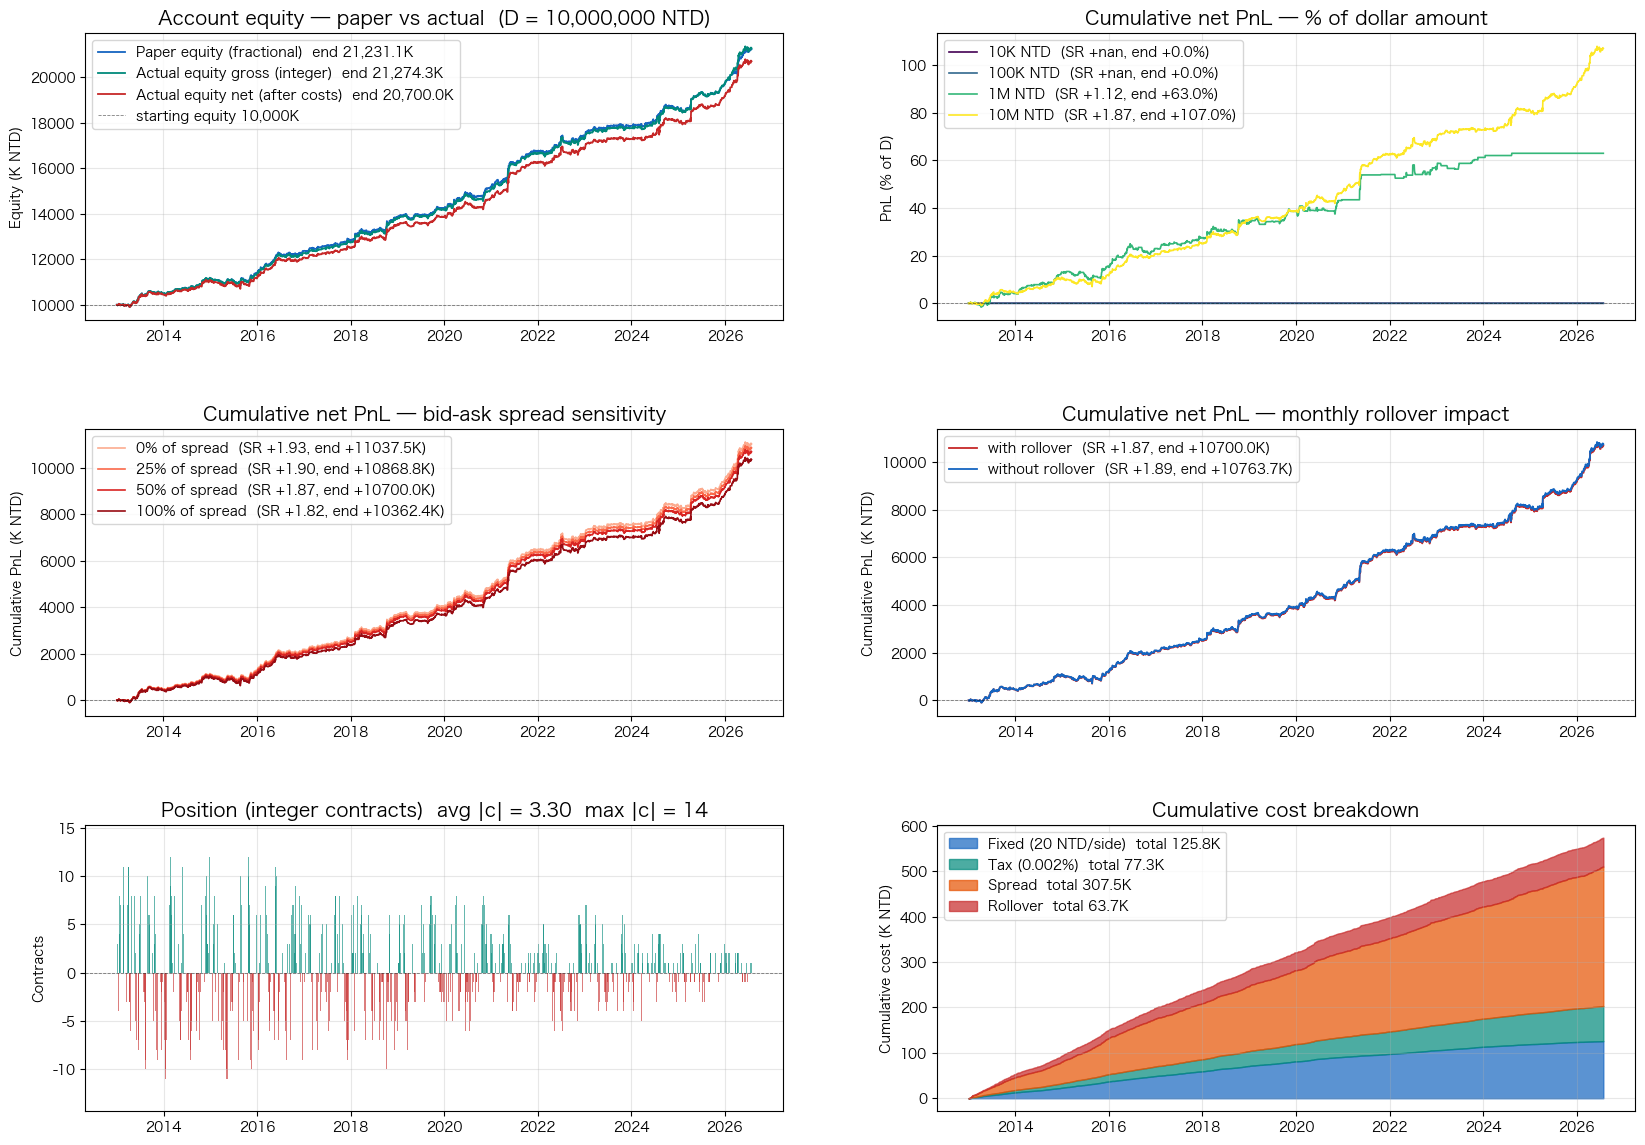

In [70]:
# ── § 8.4  Full simulate_by_dollars dashboard for the best combo ──────────

best_combo_name = comb_stats[~solo_mask].sort_values("SR", ascending=False).index[0]
print(f"best combo by full-history SR: {best_combo_name}")

# Reconstruct as a signal to feed cta.simulate_by_dollars.
# For any linear combo, the equivalent signal is a weighted sum of the sign
# components. For equal_positions: signal = mean of 5 columns. For vol_parity:
# use static weights (best_combo_name == 'vol_parity_static'); for rolling
# weights, feed the time-varying weighted signal.
if best_combo_name == "equal_positions":
    combined_sig = SIG.mean(axis=1)
elif best_combo_name == "equal_pnl":
    combined_sig = SIG.mean(axis=1)          # same signal, cost accounting differs
elif best_combo_name == "vol_parity_static":
    combined_sig = (SIG * _vols.pow(-1) / _vols.pow(-1).sum()).sum(axis=1)
elif best_combo_name == "vol_parity_roll252":
    combined_sig = (SIG * w_roll.reindex(SIG.index)).sum(axis=1)
elif best_combo_name.startswith("recent_sr"):
    wf = w_sr if "252" in best_combo_name else w_sr2
    combined_sig = (SIG * wf.reindex(SIG.index)).sum(axis=1)
elif best_combo_name == "softmax_sr_roll252":
    combined_sig = (SIG * w_sm.reindex(SIG.index)).sum(axis=1)

# Any weighted-sum of tanh-scale signals lives in ~[-1, +1]; a final tanh
# guarantees it and keeps position sizing sensible.
combined_sig = np.tanh(combined_sig).rename(best_combo_name)

_ = cta.simulate_by_dollars(combined_sig, dollar_amount=10_000_000,
                             asset="mtx", time_granularity="1d",
                             normalize=False,
                             start_date=EVAL_START, end_date=EVAL_END)


## 11. Correlation-cluster analysis — de-bias the ensemble

An equal-weight combo over 12 signals gives each raw signal a 1/12 vote — but if 5 of them cluster together on the same underlying idea (e.g., three variants of "TX log-ratio positioning"), the ensemble double- or triple-counts that idea vs a single-member cluster. This section:

1. Runs **hierarchical clustering** on the pairwise PnL correlation matrix (distance = `1 − corr`)
2. Cuts the tree at a fixed distance threshold to form **K clusters**
3. Compares three combination strategies:
   - **BASELINE** — equal-weight over all N signals (biased toward large clusters)
   - **Strategy A** (cluster-mean-then-mean) — average within each cluster to get K "cluster signals", then equal-weight the K clusters
   - **Strategy B** (best-per-cluster) — pick the single highest-`composite` signal from each cluster, then equal-weight the K picks

Strategy A retains all information; Strategy B discards intra-cluster diversification but tests whether "average of cluster is worse than the best member" (over-fitted picks) or the reverse ("cluster averaging is genuinely better than picking one").

Threshold tuning: default `distance = 0.60` (i.e. group signals with `corr > 0.40`). This gets tested at multiple thresholds to see stability.


In [71]:
# ── § 11.1  Cluster the survivors by PnL correlation + strategy comparison ─

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# Reuse the survivors set `p` and their PnL series
survivors = list(p.sort_values("composite", ascending=False).index)
n_surv = len(survivors)
print(f"survivors: {n_surv}")

# Build PnL panel (post-cost, using cta.Simulate's c2c convention as baseline)
ret_srs   = ASSET["close"].pct_change()
cost_pct2 = 20.0 / (ASSET["close"] * 50.0) + 0.00002

def _pnl_of(sig):
    ex = sig.shift(2)
    return (ex*ret_srs) - ex.fillna(0).diff().abs()*cost_pct2

PNL_MAT = pd.DataFrame({n: _pnl_of(SIGNED[n]) for n in survivors}
                       ).loc[EVAL_START:EVAL_END].fillna(0.0)
corr = PNL_MAT.corr()

# Convert to distance matrix (distance = 1 - corr, clip at 0 to be safe)
dist_arr = (1.0 - corr).clip(lower=0.0).values.copy()
np.fill_diagonal(dist_arr, 0.0)   # exact zero on diagonal
dist_condensed = squareform(dist_arr, checks=False)

# Hierarchical clustering (average linkage — robust to outliers)
Z = linkage(dist_condensed, method="average")

def _cluster_at(threshold):
    """Cut the tree at a given distance threshold. Returns dict signal → cluster_id."""
    labels = fcluster(Z, t=threshold, criterion="distance")
    return dict(zip(survivors, labels))

# Test at multiple thresholds — pick 0.60 as default (corr > 0.40 groups together)
for thr in [0.4, 0.5, 0.6, 0.7, 0.8]:
    labels = _cluster_at(thr)
    n_clu = len(set(labels.values()))
    print(f"  threshold={thr:.2f}  → {n_clu:2d} clusters")

# Use threshold=0.60 as the canonical grouping
THRESHOLD = 0.60
cluster_map = _cluster_at(THRESHOLD)
n_clusters = len(set(cluster_map.values()))
print(f"\n=== Using threshold={THRESHOLD} → {n_clusters} clusters ===\n")

# Group and display
clusters = {}
for sig, cid in cluster_map.items():
    clusters.setdefault(cid, []).append(sig)

for cid in sorted(clusters):
    members = clusters[cid]
    # Sort members by composite
    members_sorted = sorted(members, key=lambda n: -p.loc[n, "composite"])
    best_member = members_sorted[0]
    print(f"Cluster {cid} ({len(members)} member{'s' if len(members)>1 else ''}):")
    for m in members_sorted:
        marker = " ★" if m == best_member else "  "
        print(f"  {marker} {m:50s}  composite={p.loc[m,'composite']:.3f}  "
              f"SR={p.loc[m,'SR_net']:+.2f}  SR_of_SR={p.loc[m,'SR_of_SR']:+.2f}")
    print()


survivors: 12
  threshold=0.40  →  8 clusters
  threshold=0.50  →  8 clusters
  threshold=0.60  →  8 clusters
  threshold=0.70  →  7 clusters
  threshold=0.80  →  6 clusters

=== Using threshold=0.6 → 8 clusters ===

Cluster 1 (2 members):
   ★ TV_taiex_over_spy_chg_ratio_N60_pctW120             composite=0.481  SR=+0.60  SR_of_SR=+0.94
     TV_taiex_spy_ret_product_N60_pctW120                composite=0.244  SR=+0.53  SR_of_SR=+0.80

Cluster 2 (1 member):
   ★ US_log_ratio_pct_chg_W120                           composite=0.848  SR=+0.73  SR_of_SR=+1.13

Cluster 3 (1 member):
   ★ OPT_call_all_oi_signth_W20                          composite=0.402  SR=+0.76  SR_of_SR=+0.83

Cluster 4 (1 member):
   ★ OPT_put_mo_oi_selftanh_W60                          composite=0.183  SR=+0.76  SR_of_SR=+0.73

Cluster 5 (2 members):
   ★ US_sox_spy_ret_product_N5_pctW20                    composite=0.635  SR=+0.70  SR_of_SR=+0.96
     TV_sox_taiex_ret_product_N5_pctW20                  composite=0.592 

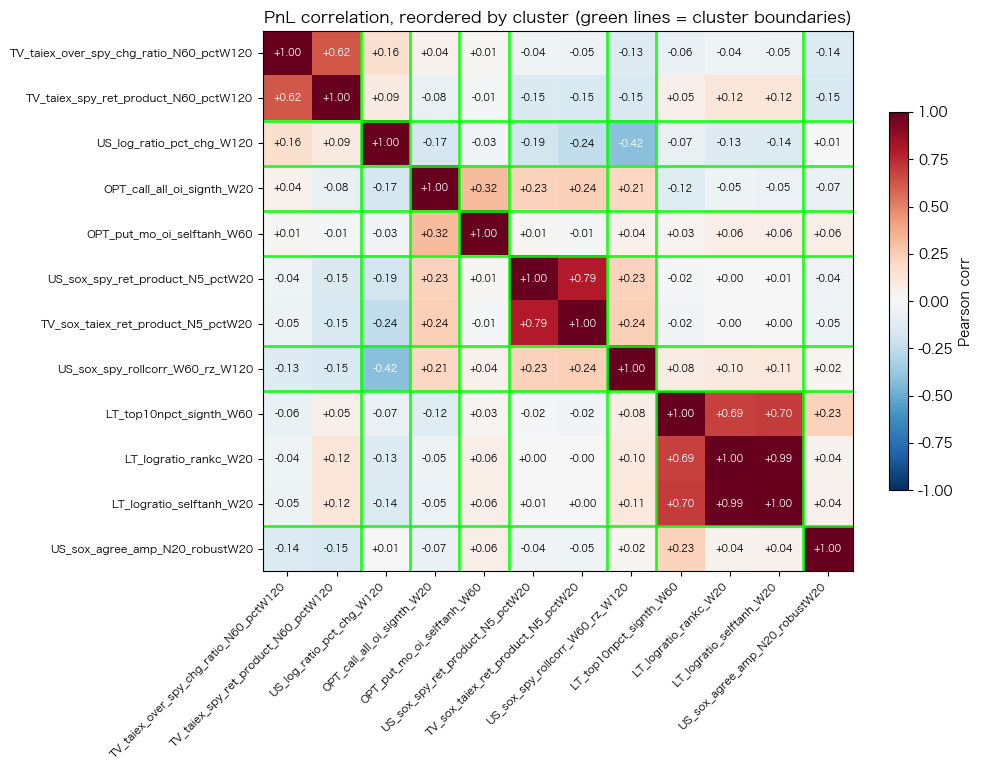


Overall off-diagonal: mean +0.056  median +0.004  max +0.987  min -0.417


In [72]:
# ── § 11.2  Correlation heatmap with cluster annotations ──────────────────

# Reorder signals by cluster to make the block structure visible
ordered = []
for cid in sorted(clusters):
    ordered.extend(sorted(clusters[cid], key=lambda n: -p.loc[n,"composite"]))
corr_o = corr.loc[ordered, ordered]

fig, ax = plt.subplots(figsize=(max(9, len(corr_o)*0.85), max(7, len(corr_o)*0.65)))
im = ax.imshow(corr_o.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_o))); ax.set_xticklabels(corr_o.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr_o))); ax.set_yticklabels(corr_o.index, fontsize=8)
for i in range(len(corr_o)):
    for j in range(len(corr_o)):
        v = corr_o.values[i,j]
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center",
                color="white" if abs(v)>0.4 else "black", fontsize=7)
# Draw cluster boundary lines
boundaries = []; pos = 0
for cid in sorted(clusters):
    pos += len(clusters[cid])
    boundaries.append(pos - 0.5)
for b in boundaries[:-1]:
    ax.axhline(b, color="lime", lw=2.0, alpha=0.85)
    ax.axvline(b, color="lime", lw=2.0, alpha=0.85)
ax.set_title(f"PnL correlation, reordered by cluster (green lines = cluster boundaries)")
plt.colorbar(im, ax=ax, shrink=0.7, label="Pearson corr")
plt.tight_layout(); plt.show()

# Numerics
off = corr.values[np.triu_indices_from(corr.values, k=1)]
print(f"\nOverall off-diagonal: mean {off.mean():+.3f}  median {np.median(off):+.3f}  "
      f"max {off.max():+.3f}  min {off.min():+.3f}")


In [73]:
# ── § 11.3  Three combination strategies compared ────────────────────────

def _sr(x):
    x = x.dropna()
    return float(np.sqrt(252) * x.mean() / x.std()) if x.std() > 0 else np.nan
def _max_dd_days(x):
    cum = x.cumsum(); dd = (cum - cum.cummax()) < 0
    if not dd.any(): return 0
    runs = dd.astype(int).groupby((dd != dd.shift()).cumsum()).sum()
    return int(runs.max())
def _stats(pnl, label):
    a = pnl.dropna()
    if len(a) == 0: return {"label": label, "SR": np.nan}
    ann_ret = a.mean() * 252; ann_vol = a.std() * np.sqrt(252)
    dd = a.cumsum() - a.cumsum().cummax()
    yr = a.groupby(a.index.year).apply(lambda x: _sr(x)).dropna()
    return {"label": label, "SR": round(_sr(a), 3),
            "ann_ret_%": round(ann_ret*100, 2), "ann_vol_%": round(ann_vol*100, 2),
            "calmar":   round(ann_ret/abs(dd.min()), 3) if dd.min()<0 else np.nan,
            "max_dd_d": _max_dd_days(a),
            "pos_yr_%": round((yr>0).mean()*100, 1),
            "worst_yr_SR": round(yr.min(), 2) if len(yr) else np.nan,
            "SR_of_SR": round(_sr(yr), 3) if yr.std() else np.nan}

# ── BASELINE — equal-weight over ALL N signals (biased to big clusters) ────
sig_baseline = pd.DataFrame(
    {n: SIGNED[n].reindex(ASSET.index) for n in survivors}
).loc[EVAL_START:EVAL_END].mean(axis=1)
pnl_baseline = _pnl_of(sig_baseline)

# ── Strategy A — cluster-mean then equal-weight over K clusters ────────────
strat_A_cluster_sigs = {}
for cid, members in clusters.items():
    cluster_sig = pd.DataFrame(
        {n: SIGNED[n].reindex(ASSET.index) for n in members}
    ).loc[EVAL_START:EVAL_END].mean(axis=1)
    strat_A_cluster_sigs[f"cluster{cid}_mean"] = cluster_sig
sig_A = pd.DataFrame(strat_A_cluster_sigs).mean(axis=1)
pnl_A = _pnl_of(sig_A)

# ── Strategy B — best signal per cluster, equal-weight over K picks ────────
picks = {}
for cid, members in clusters.items():
    best = max(members, key=lambda n: p.loc[n, "composite"])
    picks[best] = SIGNED[best]
sig_B = pd.DataFrame({n: s.reindex(ASSET.index) for n,s in picks.items()}
                     ).loc[EVAL_START:EVAL_END].mean(axis=1)
pnl_B = _pnl_of(sig_B)

# ── Score all three side by side ──────────────────────────────────────────
combo_stats = pd.DataFrame([
    _stats(pnl_baseline, f"BASELINE (N={len(survivors)}, cluster-biased)"),
    _stats(pnl_A,        f"Strategy A (cluster-mean × K={n_clusters})"),
    _stats(pnl_B,        f"Strategy B (best-per-cluster × K={n_clusters})"),
]).set_index("label")

print("=== Combination strategy comparison ===\n")
display(combo_stats.round(3))

# 2026 YTD
print("\n=== 2026 YTD ===")
for lbl, pnl in [(f"BASELINE (N={len(survivors)})", pnl_baseline),
                 (f"Strategy A (K={n_clusters} clusters)", pnl_A),
                 (f"Strategy B (K={n_clusters} best-picks)", pnl_B)]:
    ytd = pnl.loc["2026-01-01":]
    print(f"  {lbl:40s}  SR {_sr(ytd):+.3f}   ann ret {ytd.mean()*252*100:+.2f}%")

# Which picks did Strategy B choose?
print(f"\n=== Strategy B picks (one per cluster) ===")
for cid in sorted(clusters):
    best = max(clusters[cid], key=lambda n: p.loc[n, "composite"])
    print(f"  cluster {cid}: {best}   (composite={p.loc[best,'composite']:.3f})")


=== Combination strategy comparison ===



,SR,ann_ret_%,ann_vol_%,calmar,max_dd_d,pos_yr_%,worst_yr_SR,SR_of_SR
label,,,,,,,,
"BASELINE (N=12, cluster-biased)",1.957,8.84,4.52,2.369,208,100.0,0.46,38.638
Strategy A (cluster-mean × K=8),2.089,8.58,4.11,2.119,154,100.0,0.78,40.940
Strategy B (best-per-cluster × K=8),2.005,8.53,4.26,2.290,131,100.0,0.68,42.652



=== 2026 YTD ===
  BASELINE (N=12)                           SR +3.881   ann ret +29.80%
  Strategy A (K=8 clusters)                 SR +3.898   ann ret +24.97%
  Strategy B (K=8 best-picks)               SR +3.590   ann ret +23.24%

=== Strategy B picks (one per cluster) ===
  cluster 1: TV_taiex_over_spy_chg_ratio_N60_pctW120   (composite=0.481)
  cluster 2: US_log_ratio_pct_chg_W120   (composite=0.848)
  cluster 3: OPT_call_all_oi_signth_W20   (composite=0.402)
  cluster 4: OPT_put_mo_oi_selftanh_W60   (composite=0.183)
  cluster 5: US_sox_spy_ret_product_N5_pctW20   (composite=0.635)
  cluster 6: US_sox_spy_rollcorr_W60_rz_W120   (composite=0.810)
  cluster 7: LT_top10npct_signth_W60   (composite=0.685)
  cluster 8: US_sox_agree_amp_N20_robustW20   (composite=0.823)


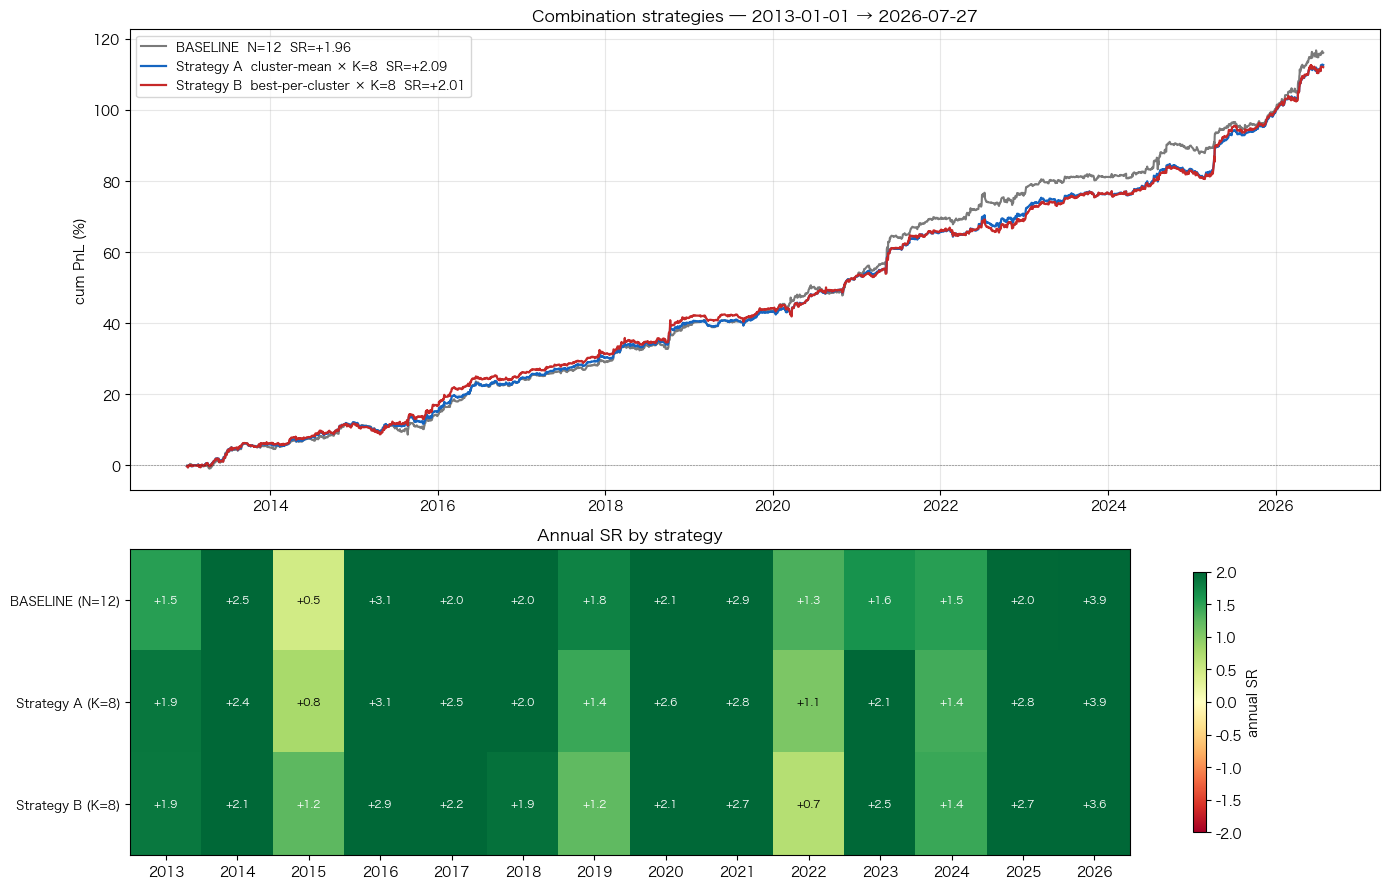

In [74]:
# ── § 11.4  Cum PnL + per-year SR heatmap for the three strategies ────────

fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios":[3,2]})

ax = axes[0]
ax.plot(pnl_baseline.cumsum() * 100, color="#7a7a7a", lw=1.5,
         label=f"BASELINE  N={len(survivors)}  SR={_sr(pnl_baseline):+.2f}")
ax.plot(pnl_A.cumsum() * 100, color="#1565c0", lw=1.6,
         label=f"Strategy A  cluster-mean × K={n_clusters}  SR={_sr(pnl_A):+.2f}")
ax.plot(pnl_B.cumsum() * 100, color="#c62828", lw=1.6,
         label=f"Strategy B  best-per-cluster × K={n_clusters}  SR={_sr(pnl_B):+.2f}")
ax.axhline(0, color="black", lw=0.4, ls="--", alpha=0.5)
ax.set_ylabel("cum PnL (%)")
ax.set_title(f"Combination strategies — {EVAL_START} → {EVAL_END}")
ax.legend(fontsize=9, loc="upper left"); ax.grid(alpha=0.3)

# Per-year SR heatmap
def _per_year_sr(p_):
    a = p_.dropna()
    return a.groupby(a.index.year).apply(lambda x: _sr(x))

ydf = pd.DataFrame({
    f"BASELINE (N={len(survivors)})": _per_year_sr(pnl_baseline),
    f"Strategy A (K={n_clusters})":  _per_year_sr(pnl_A),
    f"Strategy B (K={n_clusters})":  _per_year_sr(pnl_B),
}).T
ydf = ydf.loc[:, ydf.columns >= 2013]

ax = axes[1]
im = ax.imshow(ydf.values, cmap="RdYlGn", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(ydf.columns))); ax.set_xticklabels(ydf.columns)
ax.set_yticks(range(len(ydf))); ax.set_yticklabels(ydf.index, fontsize=9)
for i in range(ydf.shape[0]):
    for j in range(ydf.shape[1]):
        v = ydf.values[i,j]
        if np.isnan(v): continue
        ax.text(j, i, f"{v:+.1f}", ha="center", va="center",
                fontsize=8, color="white" if abs(v)>1.2 else "black")
ax.set_title("Annual SR by strategy")
plt.colorbar(im, ax=ax, shrink=0.85, label="annual SR")
plt.tight_layout(); plt.show()


In [75]:
# ── § 11.5  Sensitivity — sweep threshold to test cluster robustness ─────

thresholds = [0.40, 0.50, 0.60, 0.70, 0.80]
sens_rows = []
for thr in thresholds:
    lbl = _cluster_at(thr)
    clu_map = {}
    for sig, cid in lbl.items():
        clu_map.setdefault(cid, []).append(sig)
    K = len(clu_map)

    # Strategy A
    sig_a = pd.DataFrame({
        f"c{cid}": pd.DataFrame({n: SIGNED[n].reindex(ASSET.index) for n in mem}
                                ).loc[EVAL_START:EVAL_END].mean(axis=1)
        for cid, mem in clu_map.items()
    }).mean(axis=1)
    pnl_a = _pnl_of(sig_a)
    # Strategy B
    picks_b = {max(mem, key=lambda n: p.loc[n,"composite"]): None for mem in clu_map.values()}
    sig_b = pd.DataFrame({n: SIGNED[n].reindex(ASSET.index) for n in picks_b}
                         ).loc[EVAL_START:EVAL_END].mean(axis=1)
    pnl_b = _pnl_of(sig_b)

    sens_rows.append({
        "threshold": thr, "K_clusters": K,
        "A_SR":  round(_sr(pnl_a), 3), "B_SR":  round(_sr(pnl_b), 3),
        "A_dd_d": _max_dd_days(pnl_a.dropna()),
        "B_dd_d": _max_dd_days(pnl_b.dropna()),
    })

sens = pd.DataFrame(sens_rows).set_index("threshold")
sens["BASELINE_SR"] = round(_sr(pnl_baseline), 3)   # constant for reference

print("=== Sensitivity — cluster count vs strategy SR ===\n")
display(sens)


=== Sensitivity — cluster count vs strategy SR ===



,K_clusters,A_SR,B_SR,A_dd_d,B_dd_d,BASELINE_SR
threshold,,,,,,
0.4,8,2.089,2.005,154,131,1.957
0.5,8,2.089,2.005,154,131,1.957
0.6,8,2.089,2.005,154,131,1.957
0.7,7,2.166,1.986,140,161,1.957
0.8,6,2.140,1.903,169,151,1.957


## 12. Full dashboards for the winning aggregate signal (Strategy A)

Strategy A (cluster-mean → equal-weight across clusters) is the final aggregated signal — SR 2.09, max_dd 154d, 100% positive years, worst_yr +0.78. This section runs the full `cta.Simulate` diagnostic dashboard and the `cta.simulate_by_dollars` dashboard on it at **NT$10M account size** (adequate given MTX 2026 notional ≈ NT$2.2M/contract → ~4 contracts at signal ~0.4).


In [76]:
# ── § 12.1  Build the final aggregated signal (Strategy A) ────────────────

# Reuse `clusters` and `SIGNED` from § 11
strat_A_cluster_sigs = {}
for cid, members in clusters.items():
    cluster_sig = pd.DataFrame(
        {n: SIGNED[n].reindex(ASSET.index) for n in members}
    ).loc[EVAL_START:EVAL_END].mean(axis=1)
    strat_A_cluster_sigs[f"cluster{cid}_mean"] = cluster_sig

# Equal-weight across cluster-means, then tanh to keep signal in [-1, +1]
raw_A = pd.DataFrame(strat_A_cluster_sigs).mean(axis=1)
final_signal = np.tanh(raw_A).rename("aggregate_strategyA_clustermean")

print(f"final aggregated signal — {len(clusters)} clusters, {len(strat_A_cluster_sigs)} cluster-means, "
      f"then tanh-bounded")
print(f"  range: [{final_signal.min():+.3f}, {final_signal.max():+.3f}]  "
      f"mean: {final_signal.mean():+.3f}  std: {final_signal.std():.3f}")

# Quick stats — beta, alpha, SR, DD via batch_signal_stats
_tbl_fin = cta.batch_signal_stats({"final": final_signal}, ASSET,
                                    start=EVAL_START, end=EVAL_END, auto_flip=False)
show_cols = ["SR_gross","SR_net","alpha_ann_pct","beta","corr_bh",
             "max_dd_pct","max_dd_days","calmar","positive_years","n_years","SR_of_SR"]
print("\n=== Final signal diagnostic (c2c — matches Simulate dashboard) ===")
display(_tbl_fin[show_cols].round(3))


final aggregated signal — 8 clusters, 8 cluster-means, then tanh-bounded
  range: [-0.571, +0.583]  mean: +0.024  std: 0.223

=== Final signal diagnostic (c2c — matches Simulate dashboard) ===


,SR_gross,SR_net,alpha_ann_pct,beta,corr_bh,max_dd_pct,max_dd_days,calmar,positive_years,n_years,SR_of_SR
signal,,,,,,,,,,,
final,2.117,2.078,8.155,0.004,0.02,-3.99,154,2.061,1.0,14,2.566


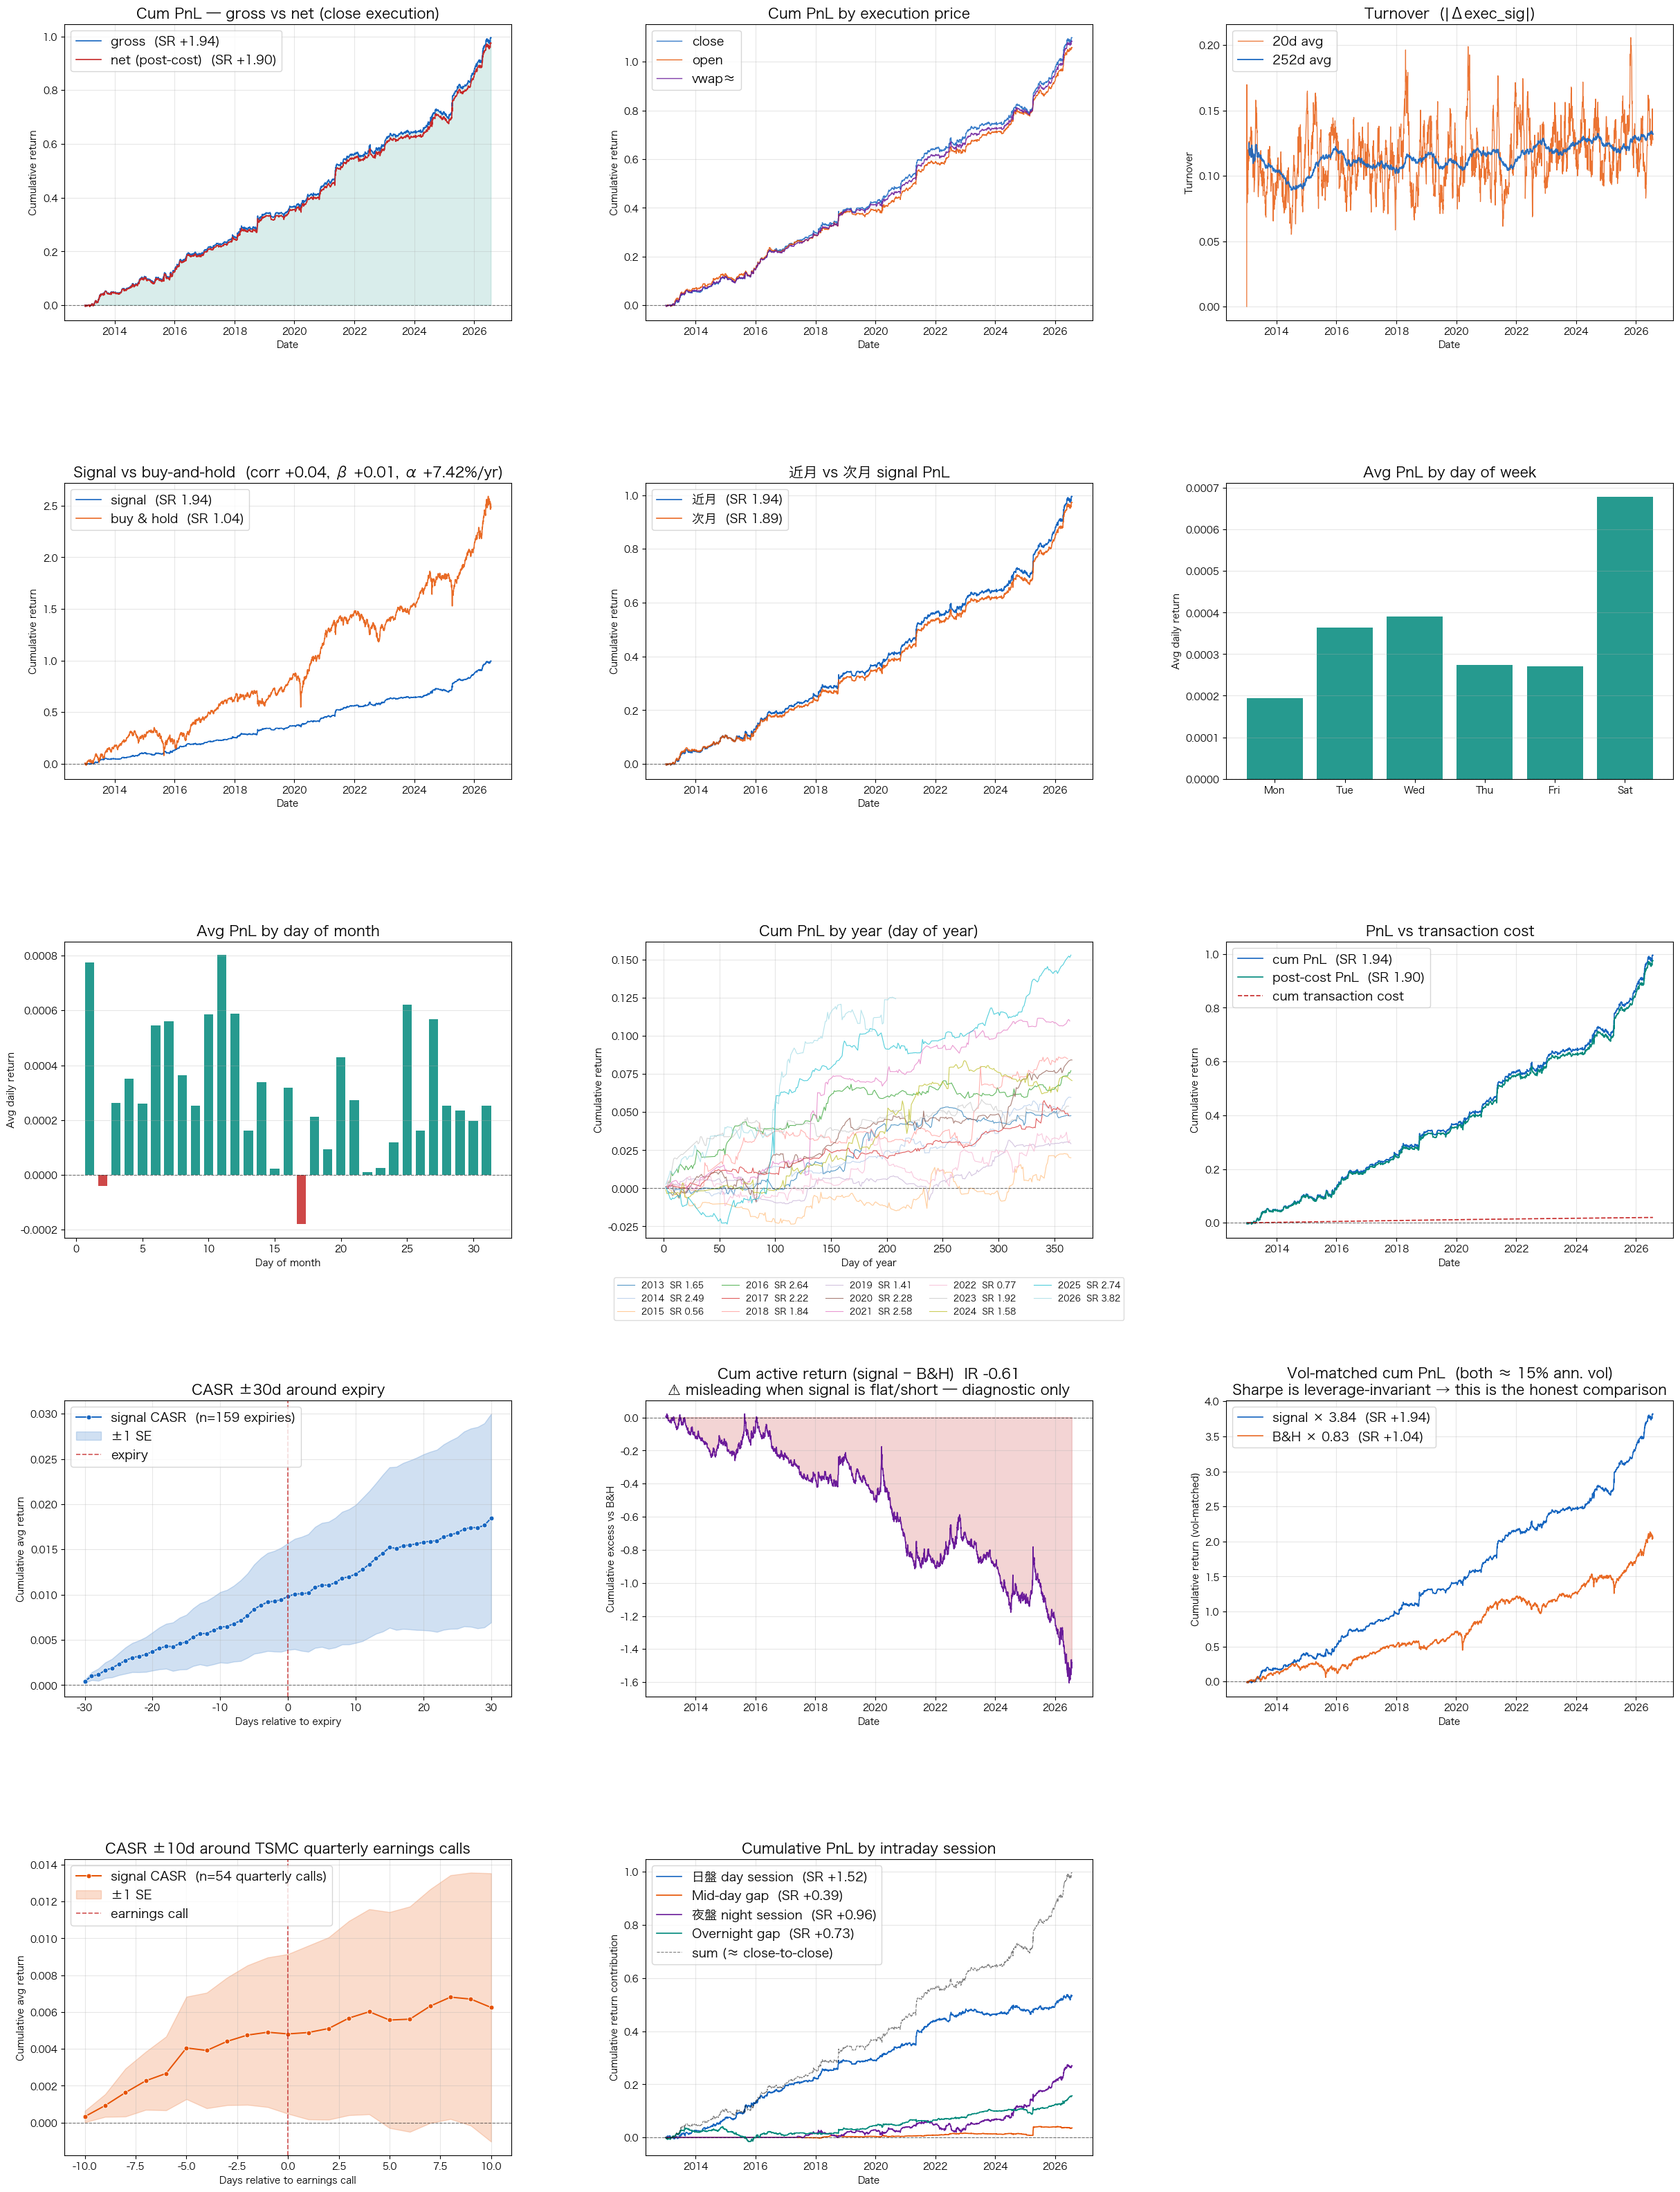

In [77]:
# ── § 12.2  cta.Simulate — full multi-panel dashboard on final signal ─────
_ = cta.Simulate(final_signal, asset="mtx", time_granularity="1d",
                 normalize=False, start_date=EVAL_START, end_date=EVAL_END)


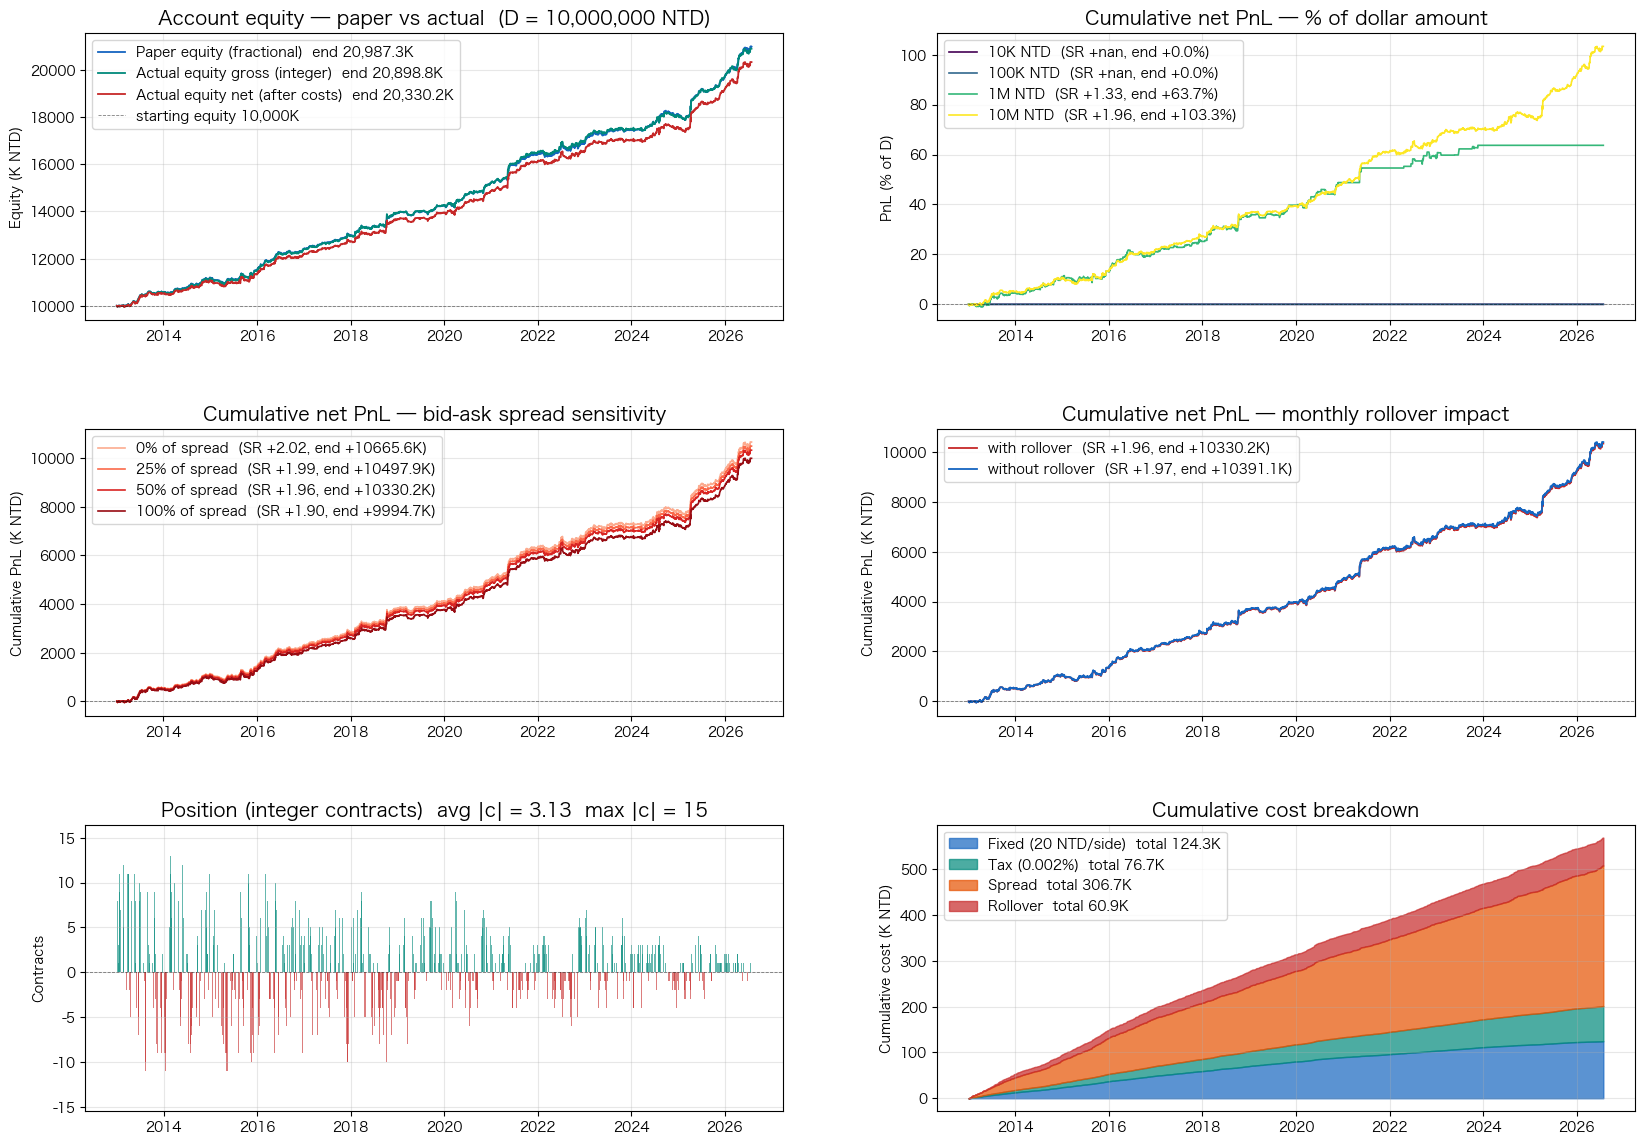

In [78]:
# ── § 12.3  simulate_by_dollars — NT$10M account ──────────────────────────
# MTX 2026 notional ≈ NT$2.2M / contract, so $10M supports ~4-5 contracts
# at typical signal magnitude — meaningful position sizes across all years.

DOLLAR = 10_000_000
_ = cta.simulate_by_dollars(final_signal, dollar_amount=DOLLAR,
                             asset="mtx", time_granularity="1d",
                             normalize=False,
                             start_date=EVAL_START, end_date=EVAL_END)


## 13. Add top-4 intraday-period winners

The existing 12 survivors all trade the standard c2c / o2o daily return (aggregated via `SimulateAll` / `Simulate` which use `signal.shift(2) × ret_c2c`). But the intraday-period sweep in [`intraday_period_signals.ipynb`](intraday_period_signals.ipynb) § 5 found that some signals do much better on **specific intraday windows** — especially the overnight `RD_ongap` (05:00 → 08:45 TPE) which is fully PIT-safe with `shift(1)`.

The **top-4 (signal × intraday period) winners** — one per source, all diversified — are added as PnL streams below.

| # | signal | intraday period | shift | period definition | SR | ann_ret |
|---|---|---|---|---|---|---|
| I1 | `OPT_put_mo_oi_selftanh_W60` | RD_ongap | 1 | `open[t] / night_close[t-1] − 1` (05:00→08:45 TPE t) | **1.97** | 25.3% |
| I2 | `LT_logratio_selftanh_W20` | RD_ongap | 1 | same | 1.79 | 27.9% |
| I3 | `LT_top10npct_signth_W60` | RD_ongap | 1 | same | 1.34 | 20.5% |
| I4 | `US_log_ratio_pct_chg_W120` | RD_ongap | 1 | same | 1.06 | 17.4% |

These 4 all trade `RD_ongap`. `shift(1)` gives 14+ hours of PIT buffer (signal at 15:00 TPE t-1 → trade at 05:00 TPE t). They are complementary to the c2c/o2o survivors: the intraday strategy captures the **overnight morning gap** specifically, while c2c/o2o captures the full 24h.

## Below — list them, score them, then combine ALL (12 c2c + 4 intraday) at the PnL level


In [ ]:
# ── § 13.1  Build the 4 intraday winners as PnL streams ──────────────────

open_  = ASSET["open"].astype(float)
n_close = ASSET["night_close"].astype(float)

# RD_ongap = overnight morning gap
ret_ongap  = open_ / n_close.shift(1) - 1
cost_ongap = 20.0 / (n_close.shift(1) * 50.0) + 0.00002    # trade cost at n_close[t-1] price

def _pnl_intraday(sig, ret, cost, shift_days=1):
    """PIT-safe intraday PnL: signal.shift(shift_days) × ret − cost."""
    ex = sig.shift(shift_days)
    return ex * ret - ex.fillna(0).diff().abs() * cost

INTRADAY_WINNERS = {
    "I1_OPT_put_mo_oi_x_RD_ongap":     SIGNED["OPT_put_mo_oi_selftanh_W60"],
    "I2_LT_logratio_selftanh_x_RD_ongap": SIGNED["LT_logratio_selftanh_W20"],
    "I3_LT_top10npct_signth_x_RD_ongap":  SIGNED["LT_top10npct_signth_W60"],
    "I4_US_log_ratio_x_RD_ongap":         SIGNED["US_log_ratio_pct_chg_W120"],
}
# Compute PnL for each (all use RD_ongap, shift 1)
INTRADAY_PNL = {n: _pnl_intraday(sig, ret_ongap, cost_ongap, shift_days=1
                                   ).loc[EVAL_START:EVAL_END] for n, sig in INTRADAY_WINNERS.items()}

# Score them
def _sr(x):
    x = x.dropna(); return float(np.sqrt(252)*x.mean()/x.std()) if x.std() > 0 else np.nan
def _max_dd_days(x):
    dd = (x.cumsum() - x.cumsum().cummax()) < 0
    if not dd.any(): return 0
    return int(dd.astype(int).groupby((dd != dd.shift()).cumsum()).sum().max())
def _stats(pnl, label):
    a = pnl.dropna()
    if len(a) == 0: return {"label": label, "SR": np.nan}
    ann_ret = a.mean() * 252; ann_vol = a.std() * np.sqrt(252)
    yr = a.groupby(a.index.year).apply(lambda x: _sr(x)).dropna()
    return {"label": label, "SR": round(_sr(a), 3),
            "ann_ret_%": round(ann_ret*100, 2),
            "ann_vol_%": round(ann_vol*100, 2),
            "max_dd_d":  _max_dd_days(a),
            "pos_yr_%":  round((yr>0).mean()*100, 1),
            "worst_yr":  round(yr.min(), 2) if len(yr) else np.nan}

intraday_rows = [_stats(v, k) for k, v in INTRADAY_PNL.items()]
print("=== Intraday-period winners (PIT-safe, shift(1) × RD_ongap) ===\n")
display(pd.DataFrame(intraday_rows).set_index("label"))


In [ ]:
# ── § 13.2  Combine 12 c2c signals + 4 intraday PnL streams ──────────────

# c2c ensemble PnL — from the existing 12 survivors, equal-weight signals
# (matches Strategy A conceptually, using shift(2) × c2c for these)
ret_c2c   = ASSET["close"].pct_change()
cost_c2c  = 20.0/(ASSET["close"]*50.0) + 0.00002

survivor_c2c_pnls = {}
for n in survivors:   # `survivors` from § 11
    ex = SIGNED[n].shift(2)
    survivor_c2c_pnls[n] = ((ex*ret_c2c) - ex.fillna(0).diff().abs()*cost_c2c).loc[EVAL_START:EVAL_END]

# Ensemble methods — 3 flavors
c2c_only_ensemble = pd.DataFrame(survivor_c2c_pnls).sum(axis=1) / len(survivors)
intraday_only_ens = pd.DataFrame(INTRADAY_PNL).sum(axis=1) / len(INTRADAY_PNL)
combined_ensemble = pd.DataFrame({**survivor_c2c_pnls, **INTRADAY_PNL}
                                 ).sum(axis=1) / (len(survivors) + len(INTRADAY_PNL))

comparison = pd.DataFrame([
    _stats(c2c_only_ensemble, f"c2c ensemble (N={len(survivors)}, equal-weight)"),
    _stats(intraday_only_ens, f"intraday ensemble (N={len(INTRADAY_PNL)}, equal-weight)"),
    _stats(combined_ensemble, f"combined c2c + intraday (N={len(survivors)+len(INTRADAY_PNL)}, equal-weight)"),
]).set_index("label")

print("=== 3-way ensemble comparison ===\n")
display(comparison.round(3))

# 2026 YTD
print("\n=== 2026 YTD ===")
for lbl, pnl in [("c2c only", c2c_only_ensemble),
                 ("intraday only", intraday_only_ens),
                 ("combined c2c + intraday", combined_ensemble)]:
    ytd = pnl.loc["2026-01-01":]
    print(f"  {lbl:32s}  SR {_sr(ytd):+.3f}   ann ret {ytd.mean()*252*100:+.2f}%")

# Cum PnL plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(c2c_only_ensemble.cumsum()*100, color="#1565c0", lw=1.5,
         label=f"c2c only (N={len(survivors)}, SR {_sr(c2c_only_ensemble):+.2f})")
ax.plot(intraday_only_ens.cumsum()*100, color="#c62828", lw=1.5,
         label=f"intraday only (N=4, SR {_sr(intraday_only_ens):+.2f})")
ax.plot(combined_ensemble.cumsum()*100, color="#2e7d32", lw=1.8,
         label=f"combined (N=16, SR {_sr(combined_ensemble):+.2f})")
ax.axhline(0, color="black", lw=0.4, ls="--", alpha=0.5)
ax.set_ylabel("cum PnL (%)")
ax.set_title(f"c2c ensemble vs intraday ensemble vs combined — {EVAL_START} → {EVAL_END}")
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
